[LOAD 9100] MDEG= 8  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=12  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=16  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=20  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits  shape=(3459, 438, 437)
[LOAD 7000] MDEG= 8  file=IC3392_v3tk_mask_uptoCONT_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=12  file=IC3392_v3tk_mask_uptoCONT_MDEG12_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=16  file=IC3392_v3tk_mask_uptoCONT_MDEG16_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=20  file=IC3392_v3tk_mask_uptoCONT_MDEG20_line_cube.fits  shape=(1770, 438, 437)
[LOAD ORIG] IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits  shape=(3761, 438, 437)
[CONT] p90(|cont|)=68.17, floor=0.06817
[NOISE] median sigma(5218-5485)=4.953
[SAMPLE] Using 20000 spaxels out of 96620

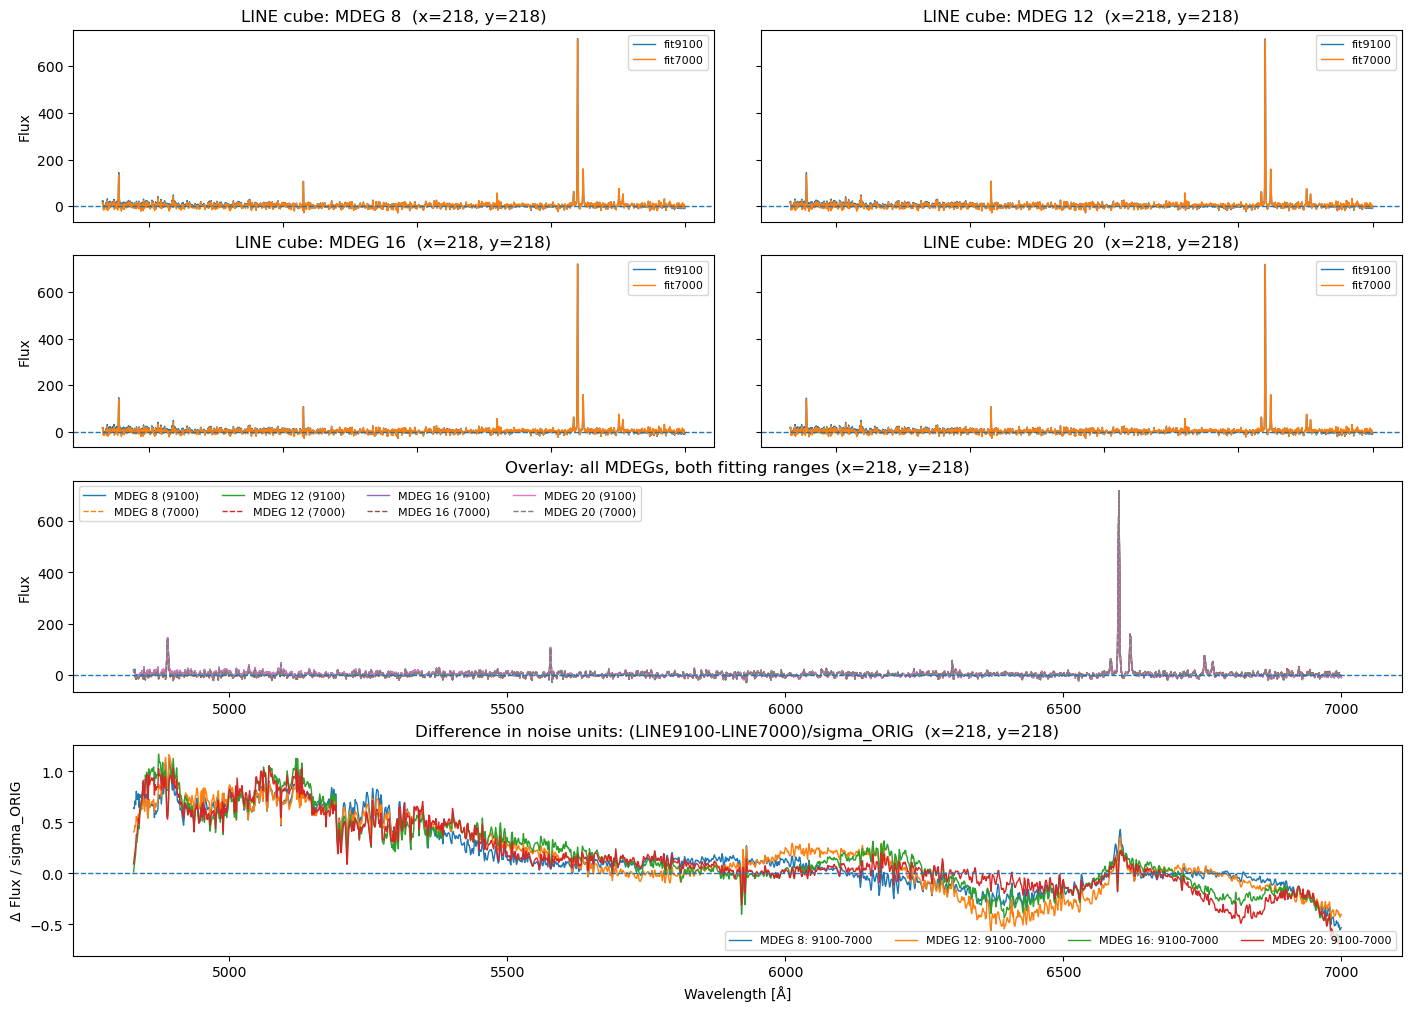

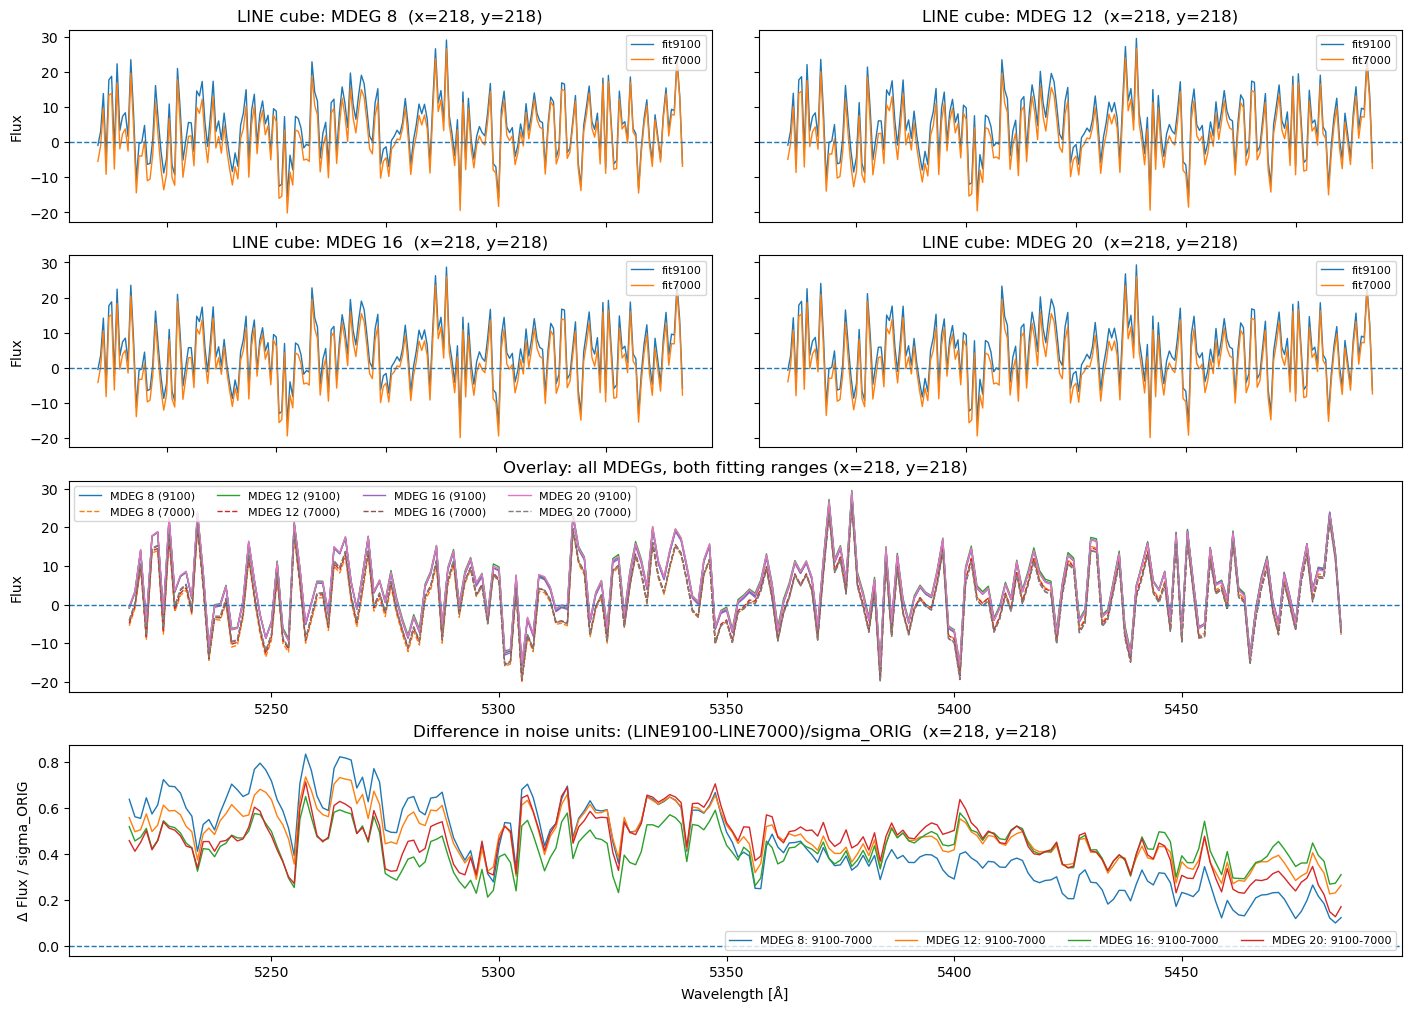

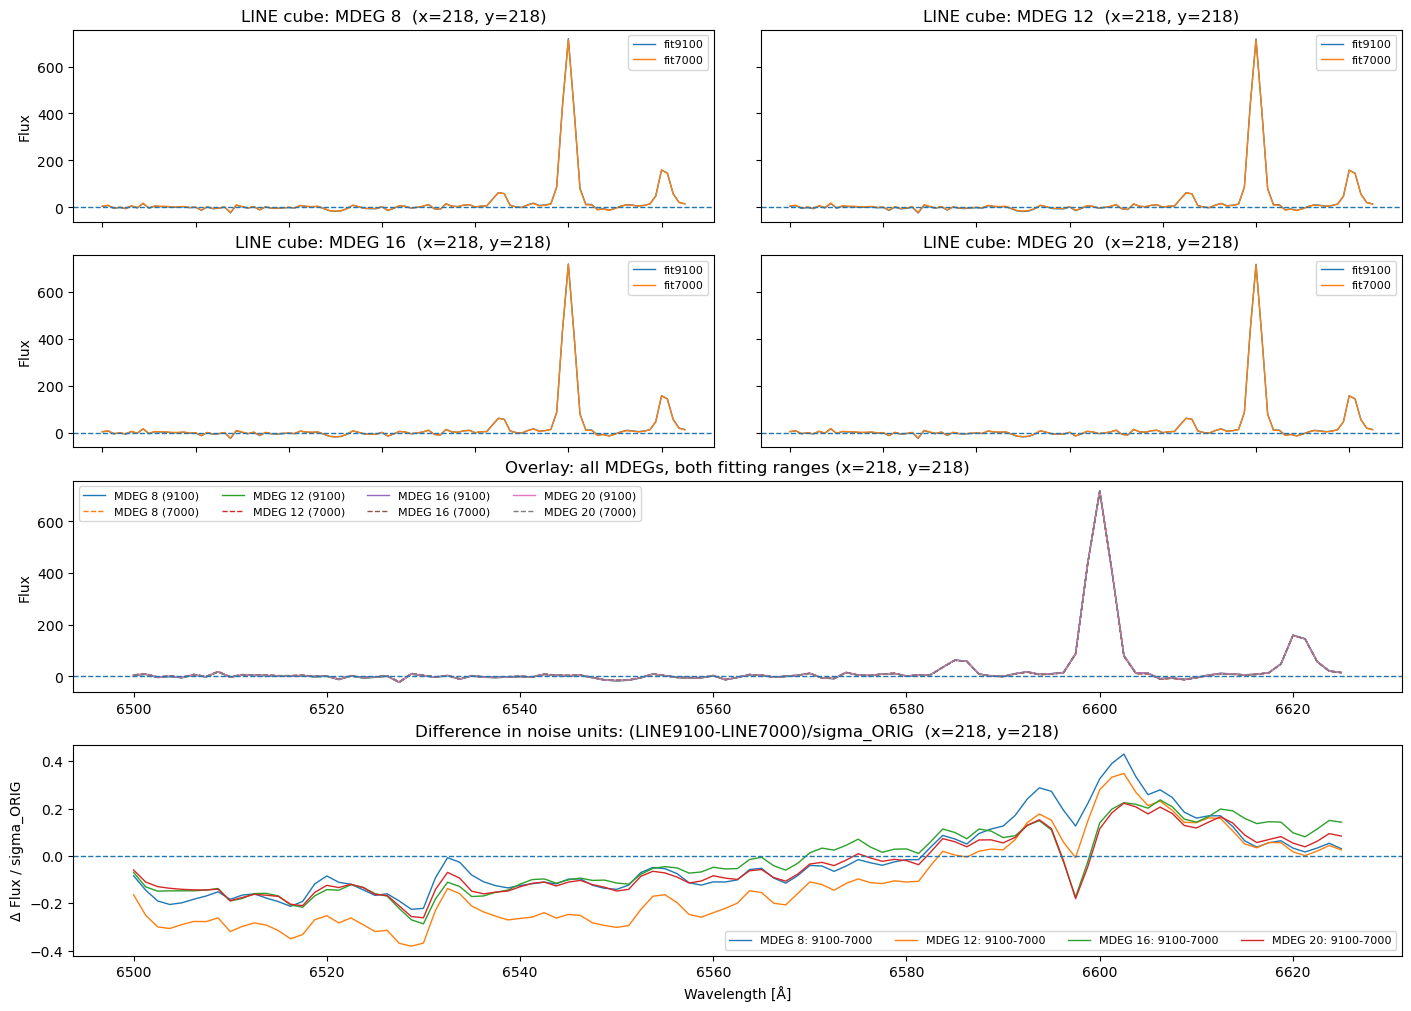

In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)

# -----------------------------
# USER SETTINGS
# -----------------------------
base = Path.cwd()

run_ids_9100 = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}

run_ids_7000 = {
    8:  "IC3392_v3tk_mask_uptoCONT",
    12: "IC3392_v3tk_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_mask_uptoCONT_MDEG20",
}

if sorted(run_ids_9100) != sorted(run_ids_7000):
    raise ValueError("MDEG keys mismatch between 9100 and 7000 datasets")

MDEGS = sorted(run_ids_9100)
run_ids = run_ids_9100  # keep legacy name for later cells

linecube_name = lambda rid: base / rid / f"{rid}_line_cube.fits"

ORIG_CUBE_PATH = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")

windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "Hb_edge_4800_4920": (4800.0, 4920.0),
    "OIII_edge_4940_5060": (4940.0, 5060.0),
    "HaNII_edge_6500_6625": (6500.0, 6625.0),
    "SII_edge_6680_6760": (6680.0, 6760.0),
}

NSAMPLE  = 20000
STRIDE   = 4
NCPU     = min(os.cpu_count() or 8, 16)
DENOM_FLOOR_FRAC = 1e-3
CONT_FLOOR_FRAC = 1e-3
CONT_WIN = (5218.0, 5485.0)


# -----------------------------
# FITS HELPERS
# -----------------------------
def wave_from_fits_header(hdr):
    crval = hdr["CRVAL3"]
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3"))
    crpix = hdr.get("CRPIX3", 1.0)
    n = hdr["NAXIS3"]
    pix = np.arange(n) + 1
    return crval + (pix - crpix) * cdelt

def open_memmap_cube(path):
    hdul = fits.open(path, memmap=True)
    cube = hdul[0].data
    wave = wave_from_fits_header(hdul[0].header)
    return hdul, cube, wave

def open_memmap_cube_anyhdu(path: Path):
    hdul = fits.open(path, memmap=True)
    hdu = None
    for hh in hdul:
        if getattr(hh, "data", None) is None:
            continue
        if hh.data is None:
            continue
        if hh.data.ndim == 3 and hh.name.upper() != "STAT":
            hdu = hh
            break
    if hdu is None:
        raise RuntimeError(f"No 3D flux cube found in {path}")

    if "STAT" not in hdul:
        raise RuntimeError(f"STAT extension not found in {path}")
    stat_hdu = hdul["STAT"]
    if getattr(stat_hdu, "data", None) is None or stat_hdu.data.ndim != 3:
        raise RuntimeError(f"STAT extension is not a 3D variance cube in {path}")

    cube = hdu.data
    var_cube = stat_hdu.data
    wave = wave_from_fits_header(hdu.header)
    return hdul, cube, var_cube, wave

def continuum_level_map(cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Continuum window has no samples on this wavelength grid.")
    return np.nanmedian(cube[idx, :, :], axis=0)

def noise_level_map(var_cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Noise window has no samples on this wavelength grid.")
    med_var = np.nanmedian(var_cube[idx, :, :], axis=0)
    return np.sqrt(np.clip(med_var, 0.0, None))

def interp_spec_to_wave(spec_in, wave_in, wave_out):
    ok = np.isfinite(spec_in) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out, np.nan, dtype=float)
    return np.interp(wave_out, wave_in[ok], spec_in[ok], left=np.nan, right=np.nan)


def load_dataset(run_map, label):
    hduls, cubes, waves = {}, {}, {}
    for mdeg, rid in run_map.items():
        f = linecube_name(rid)
        hdul, cube, wave = open_memmap_cube(f)
        hduls[mdeg] = hdul
        cubes[mdeg] = cube
        waves[mdeg] = wave
        print(f"[LOAD {label}] MDEG={mdeg:>2}  file={f.name}  shape={cube.shape}")

    ref_spatial = cubes[MDEGS[0]].shape[1:]
    for mdeg in MDEGS:
        if cubes[mdeg].shape[1:] != ref_spatial:
            raise ValueError(f"{label}: spatial shape mismatch at MDEG {mdeg}: {cubes[mdeg].shape[1:]} vs {ref_spatial}")
    return hduls, cubes, waves[MDEGS[0]], ref_spatial


# -----------------------------
# LOAD BOTH FITTING-RANGE DATASETS
# -----------------------------
hduls_9100, cubes_9100, wave_9100, spatial_9100 = load_dataset(run_ids_9100, "9100")
hduls_7000, cubes_7000, wave_7000, spatial_7000 = load_dataset(run_ids_7000, "7000")

if spatial_9100 != spatial_7000:
    raise ValueError("Cross-range spatial shape mismatch between 9100 and 7000 datasets")

if not np.allclose(wave_9100[: min(len(wave_9100), len(wave_7000))], wave_7000[: min(len(wave_9100), len(wave_7000))], atol=1e-6, rtol=0):
    print("[WARN] wavelength grids differ; interpolation will be used where direct subtraction is needed")

ref_wave = wave_7000

datasets = {
    "9100": {"hduls": hduls_9100, "cubes": cubes_9100, "wave": wave_9100},
    "7000": {"hduls": hduls_7000, "cubes": cubes_7000, "wave": wave_7000},
}

# legacy aliases retained for downstream cells
hduls = hduls_9100
cubes = cubes_9100

# Load ORIGINAL flux cube + STAT variance cube
hdul_orig, cube_orig, var_orig, wave_orig = open_memmap_cube_anyhdu(ORIG_CUBE_PATH)
print(f"[LOAD ORIG] {ORIG_CUBE_PATH.name}  shape={cube_orig.shape}")

if cube_orig.shape[1:] != spatial_9100:
    raise ValueError(f"ORIG cube spatial shape mismatch: {cube_orig.shape[1:]} vs {spatial_9100}")
if var_orig.shape != cube_orig.shape:
    raise ValueError(f"STAT variance shape mismatch: {var_orig.shape} vs {cube_orig.shape}")

cont_map = continuum_level_map(cube_orig, wave_orig, *CONT_WIN)
cont_finite = np.isfinite(cont_map)
cont_scale = np.nanpercentile(np.abs(cont_map[cont_finite]), 90)
CONT_FLOOR = cont_scale * CONT_FLOOR_FRAC
print(f"[CONT] p90(|cont|)={cont_scale:.4g}, floor={CONT_FLOOR:.4g}")

noise_map = noise_level_map(var_orig, wave_orig, *CONT_WIN)
noise_finite = np.isfinite(noise_map)
noise_scale = np.nanpercentile(noise_map[noise_finite], 50)
print(f"[NOISE] median sigma({CONT_WIN[0]:.0f}-{CONT_WIN[1]:.0f})={noise_scale:.4g}")


# -----------------------------
# BUILD RANDOM SPAXEL SAMPLE (valid in both ranges)
# -----------------------------
w1_ref, w2_ref = windows["cont_5218_5485"]
idx_ref_9100 = (wave_9100 >= w1_ref) & (wave_9100 <= w2_ref)
idx_ref_7000 = (wave_7000 >= w1_ref) & (wave_7000 <= w2_ref)

sub_9100_ref = cubes_9100[MDEGS[0]][idx_ref_9100, :, :]
sub_7000_ref = cubes_7000[MDEGS[0]][idx_ref_7000, :, :]
valid_ref = np.isfinite(sub_9100_ref).any(axis=0) & np.isfinite(sub_7000_ref).any(axis=0)

yy, xx = np.where(valid_ref)
n_valid = yy.size
if n_valid == 0:
    raise RuntimeError("No valid spaxels found in both ranges for the reference window")

rng = np.random.default_rng(42)
take = min(NSAMPLE, n_valid)
sel_idx = rng.choice(n_valid, size=take, replace=False)
ys = yy[sel_idx]
xs = xx[sel_idx]
print(f"[SAMPLE] Using {take} spaxels out of {n_valid} jointly-valid spaxels")
print(f"[PARALLEL] Using {NCPU} threads")

cont_samp = cont_map[ys, xs]
cont_samp_denom = np.sign(cont_samp) * np.maximum(np.abs(cont_samp), CONT_FLOOR)
noise_samp = noise_map[ys, xs]


# -----------------------------
# STATS HELPERS (PER RANGE, PER MDEG)
# -----------------------------
def compute_window_stats_for_dataset(dataset_key, mdeg, w1, w2):
    cube = datasets[dataset_key]["cubes"][mdeg]
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return dataset_key, mdeg, None, np.full(take, np.nan), np.full(take, np.nan)

    slab = cube[idx, :, :]
    sub = slab[:, ys, xs]

    valid = np.isfinite(sub).any(axis=0)
    med_all = np.full(take, np.nan, dtype=float)
    rms_all = np.full(take, np.nan, dtype=float)

    if valid.sum() == 0:
        return dataset_key, mdeg, {"n_valid": 0, "n_tot": int(valid.size)}, med_all, rms_all

    subv = sub[:, valid]
    med = np.nanmedian(subv, axis=0)
    mad = np.nanmedian(np.abs(subv - med[None, :]), axis=0)
    rms = 1.4826 * mad

    med_all[valid] = med
    rms_all[valid] = rms

    stats = {
        "n_valid": int(valid.sum()),
        "n_tot": int(valid.size),
        "med_p16": float(np.nanpercentile(med, 16)),
        "med_p50": float(np.nanpercentile(med, 50)),
        "med_p84": float(np.nanpercentile(med, 84)),
        "rms_p16": float(np.nanpercentile(rms, 16)),
        "rms_p50": float(np.nanpercentile(rms, 50)),
        "rms_p84": float(np.nanpercentile(rms, 84)),
    }
    return dataset_key, mdeg, stats, med_all, rms_all


def window_rms_map(dataset_key, mdeg, w1, w2, stride=4):
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return None
    slab = datasets[dataset_key]["cubes"][mdeg][idx, ::stride, ::stride]
    med = np.nanmedian(slab, axis=0)
    mad = np.nanmedian(np.abs(slab - med[None, :, :]), axis=0)
    return 1.4826 * mad


# # -----------------------------
# # MAIN WINDOW LOOP: (9100 - 7000) at fixed MDEG
# # -----------------------------
# for wname, (w1, w2) in windows.items():
#     print("\n" + "=" * 90)
#     print(f"WINDOW: {wname}  ({w1:.1f}–{w2:.1f} Å)")

#     stats_by = {"9100": {}, "7000": {}}
#     med_by = {"9100": {}, "7000": {}}
#     rms_by = {"9100": {}, "7000": {}}

#     with ThreadPoolExecutor(max_workers=NCPU) as ex:
#         futures = [
#             ex.submit(compute_window_stats_for_dataset, dk, mdeg, w1, w2)
#             for dk in ("9100", "7000")
#             for mdeg in MDEGS
#         ]
#         for fut in as_completed(futures):
#             dk, mdeg, stats, med_all, rms_all = fut.result()
#             stats_by[dk][mdeg] = stats
#             med_by[dk][mdeg] = med_all
#             rms_by[dk][mdeg] = rms_all

#     print("\n  Absolute summaries by fitting range:")
#     for mdeg in MDEGS:
#         for dk in ("9100", "7000"):
#             s = stats_by[dk][mdeg]
#             if s is None or s.get("n_valid", 0) == 0:
#                 print(f"    MDEG={mdeg:>2} [{dk}]: no valid sampled spaxels")
#                 continue
#             print(
#                 f"    MDEG={mdeg:>2} [{dk}]: "
#                 f"med=({s['med_p16']:.4g},{s['med_p50']:.4g},{s['med_p84']:.4g})  "
#                 f"rms=({s['rms_p16']:.4g},{s['rms_p50']:.4g},{s['rms_p84']:.4g})  "
#                 f"N={s['n_valid']}/{s['n_tot']}"
#             )

#     print("\n  Cross-fitting-range comparison (9100 - 7000) at fixed MDEG:")
#     drms_pct_by_mdeg = {}
#     dmed_by_mdeg = {}

#     for mdeg in MDEGS:
#         med9100 = med_by["9100"][mdeg]
#         med7000 = med_by["7000"][mdeg]
#         rms9100 = rms_by["9100"][mdeg]
#         rms7000 = rms_by["7000"][mdeg]

#         ok = np.isfinite(med9100) & np.isfinite(med7000) & np.isfinite(rms9100) & np.isfinite(rms7000)
#         if ok.sum() == 0:
#             print(f"    MDEG={mdeg:>2}: no overlap-valid spaxels")
#             drms_pct_by_mdeg[mdeg] = np.array([])
#             dmed_by_mdeg[mdeg] = np.array([])
#             continue

#         dmed = med9100[ok] - med7000[ok]
#         drms = rms9100[ok] - rms7000[ok]

#         denom_ok = np.isfinite(rms7000[ok]) & (rms7000[ok] > 0)
#         if denom_ok.any():
#             floor = np.nanpercentile(rms7000[ok][denom_ok], 5) * DENOM_FLOOR_FRAC
#             denom = np.maximum(rms7000[ok], floor)
#             drms_pct = drms / denom * 100.0
#         else:
#             drms_pct = np.full(ok.sum(), np.nan)

#         dmed_by_mdeg[mdeg] = dmed
#         drms_pct_by_mdeg[mdeg] = drms_pct[np.isfinite(drms_pct)]

#         p16m, p50m, p84m = np.nanpercentile(dmed, [16, 50, 84])
#         p16r, p50r, p84r = np.nanpercentile(drms, [16, 50, 84])
#         print(
#             f"    MDEG={mdeg:>2}: ΔMED=(p16,p50,p84)=({p16m:.3g},{p50m:.3g},{p84m:.3g})  "
#             f"ΔRMS(abs)=({p16r:.3g},{p50r:.3g},{p84r:.3g})"
#         )

#         if drms_pct_by_mdeg[mdeg].size > 0:
#             p16, p50, p84 = np.nanpercentile(drms_pct_by_mdeg[mdeg], [16, 50, 84])
#             print(f"              ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000: ({p16:.3g}, {p50:.3g}, {p84:.3g})")

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = drms_pct_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"ΔRMS[%] between fitting ranges (9100-7000): {wname}")
    # plt.xlabel("100*(RMS9100 - RMS7000) / RMS7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = dmed_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"Δ median residual (9100-7000): {wname}")
    # plt.xlabel("Median9100 - Median7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # for mdeg in MDEGS:
    #     rms_9100_map = window_rms_map("9100", mdeg, w1, w2, stride=STRIDE)
    #     rms_7000_map = window_rms_map("7000", mdeg, w1, w2, stride=STRIDE)

    #     if rms_9100_map is None or rms_7000_map is None:
    #         continue

    #     finite_7000 = np.isfinite(rms_7000_map) & (rms_7000_map > 0)
    #     if not finite_7000.any():
    #         continue

    #     floor = np.nanpercentile(rms_7000_map[finite_7000], 5) * DENOM_FLOOR_FRAC
    #     denom = np.maximum(rms_7000_map, floor)
    #     pct_map = (rms_9100_map - rms_7000_map) / denom * 100.0

    #     finite = np.isfinite(pct_map)
    #     v = np.nanpercentile(np.abs(pct_map[finite]), 99) if finite.any() else 10.0

    #     plt.figure(figsize=(6, 5))
    #     plt.imshow(pct_map, origin="lower", vmin=-v, vmax=v)
    #     plt.colorbar(label=f"ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000  (MDEG={mdeg}, stride={STRIDE})")
    #     plt.title(f"% RMS-change map (9100-7000): {wname}, MDEG={mdeg}")
    #     plt.xlabel("x [pix/stride]")
    #     plt.ylabel("y [pix/stride]")
    #     plt.show()


# -----------------------------
# SPAXEL SPECTRUM OVERLAY (x,y from Mapviewer)
# -----------------------------
XPIX = 218
YPIX = 218

def plot_spaxel_suite(
    x, y,
    mdegs=(8, 12, 16, 20),
    wmin=4800,
    wmax=7000,
):
    w9100 = wave_9100
    w7000 = wave_7000
    sel9100 = (w9100 >= wmin) & (w9100 <= wmax)
    sel7000 = (w7000 >= wmin) & (w7000 <= wmax)

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = GridSpec(nrows=4, ncols=2, figure=fig, height_ratios=[1, 1, 1.1, 1.1])

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
    ax10 = fig.add_subplot(gs[1, 0], sharey=ax00)
    ax11 = fig.add_subplot(gs[1, 1], sharey=ax00)
    axes_ind = [ax00, ax01, ax10, ax11]

    ax_overlay = fig.add_subplot(gs[2, :], sharex=ax00)
    ax_diff = fig.add_subplot(gs[3, :], sharex=ax00)

    for ax, mdeg in zip(axes_ind, mdegs):
        s9100 = cubes_9100[mdeg][:, y, x]
        s7000 = cubes_7000[mdeg][:, y, x]

        g9100 = sel9100 & np.isfinite(s9100)
        g7000 = sel7000 & np.isfinite(s7000)

        ax.plot(w9100[g9100], s9100[g9100], lw=1, label="fit9100")
        ax.plot(w7000[g7000], s7000[g7000], lw=1, label="fit7000")
        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"LINE cube: MDEG {mdeg}  (x={x}, y={y})")
        ax.set_ylabel("Flux")
        ax.legend(loc="upper right", fontsize=8)

    for ax in axes_ind:
        ax.label_outer()

    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        s7000 = cubes_7000[mdeg][:, y, x]
        g9100 = sel9100 & np.isfinite(s9100)
        g7000 = sel7000 & np.isfinite(s7000)
        ax_overlay.plot(w9100[g9100], s9100[g9100], lw=1, label=f"MDEG {mdeg} (9100)")
        ax_overlay.plot(w7000[g7000], s7000[g7000], lw=1, ls="--", label=f"MDEG {mdeg} (7000)")

    ax_overlay.axhline(0, ls="--", lw=1)
    ax_overlay.set_title(f"Overlay: all MDEGs, both fitting ranges (x={x}, y={y})")
    ax_overlay.set_ylabel("Flux")
    ax_overlay.legend(ncol=4, fontsize=8, loc="upper left")

    sigma0 = np.sqrt(np.clip(var_orig[:, y, x], 0.0, None))
    sigma0_on_7000 = interp_spec_to_wave(sigma0, wave_orig, w7000)

    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        s7000 = cubes_7000[mdeg][:, y, x]
        s9100_on_7000 = interp_spec_to_wave(s9100, w9100, w7000)
        d_abs = s9100_on_7000 - s7000
        d_over_noise = d_abs / sigma0_on_7000
        good = sel7000 & np.isfinite(d_over_noise)
        if good.any():
            ax_diff.plot(w7000[good], d_over_noise[good], lw=1, label=f"MDEG {mdeg}: 9100-7000")

    ax_diff.axhline(0, ls="--", lw=1)
    ax_diff.set_title(
        f"Difference in noise units: (LINE9100-LINE7000)/sigma_ORIG  (x={x}, y={y})"
    )
    ax_diff.set_xlabel("Wavelength [Å]")
    ax_diff.set_ylabel("Δ Flux / sigma_ORIG")
    ax_diff.legend(ncol=min(4, len(mdegs)), loc="lower right", fontsize=8)

    plt.show()


plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=4800, wmax=7000)
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=5218, wmax=5485)
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=6500, wmax=6625)


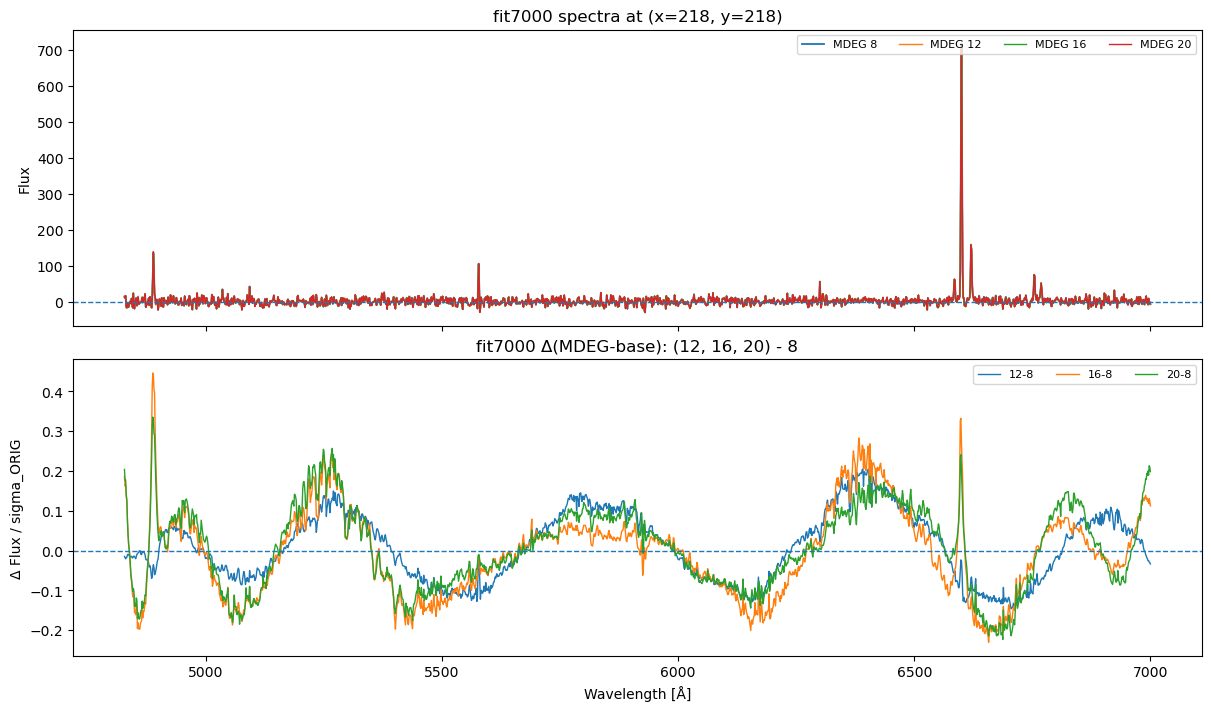

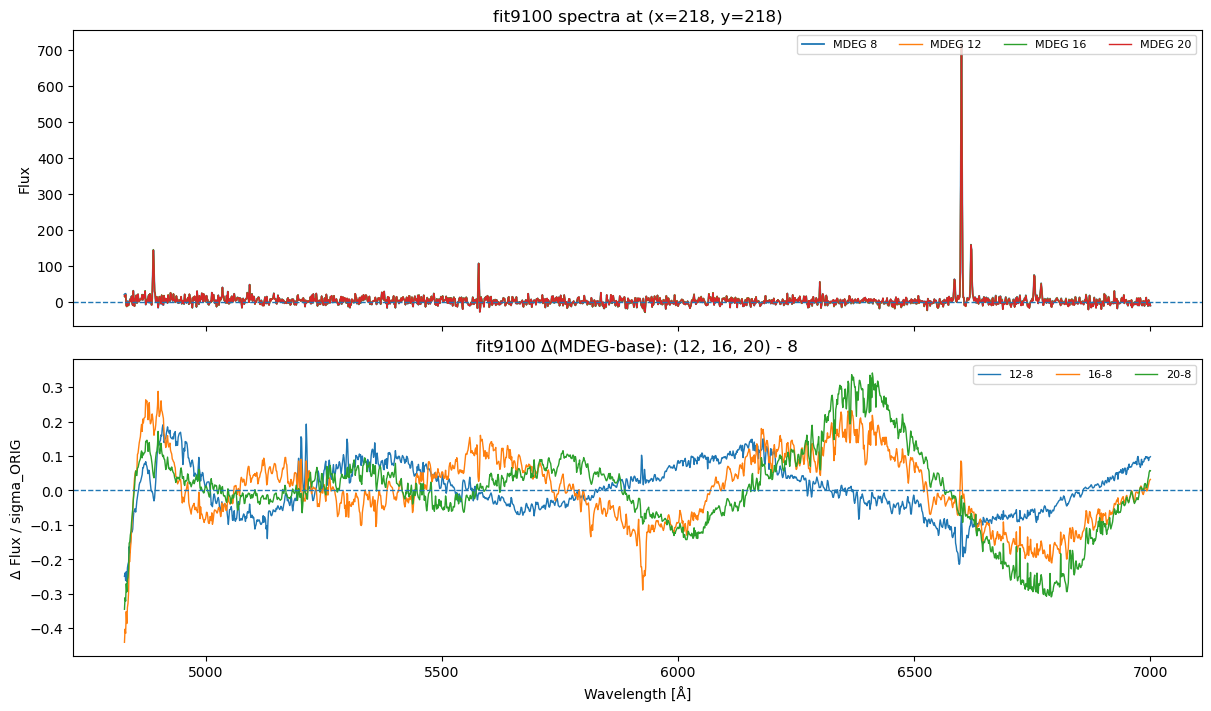

In [2]:
# CELL 2: separate figures for within-range MDEG differences
def plot_within_range_mdeg_diff_separate(
    x, y,
    base_mdeg=8,
    comp_mdegs=(12, 16, 20),
    wmin=4800,
    wmax=7000,
    normalize_by_noise=True,
):
    def _plot_single_range(range_label, wave, cubes_dict):
        sel = (wave >= wmin) & (wave <= wmax)
        base_spec = cubes_dict[base_mdeg][:, y, x]

        fig, (ax_spec, ax_diff) = plt.subplots(
            2, 1, figsize=(12, 7), sharex=True, constrained_layout=True
        )

        gbase = sel & np.isfinite(base_spec)
        ax_spec.plot(wave[gbase], base_spec[gbase], lw=1.3, label=f"MDEG {base_mdeg}")

        sigma = None
        if normalize_by_noise:
            sigma = np.sqrt(np.clip(interp_spec_to_wave(var_orig[:, y, x], wave_orig, wave), 0.0, None))

        for mdeg in comp_mdegs:
            spec = cubes_dict[mdeg][:, y, x]
            g = sel & np.isfinite(spec)
            ax_spec.plot(wave[g], spec[g], lw=1.0, label=f"MDEG {mdeg}")

            d = spec - base_spec
            if normalize_by_noise and sigma is not None:
                d = d / sigma

            gd = sel & np.isfinite(d)
            if gd.any():
                ax_diff.plot(wave[gd], d[gd], lw=1.0, label=f"{mdeg}-{base_mdeg}")

        ax_spec.axhline(0, ls="--", lw=1)
        ax_diff.axhline(0, ls="--", lw=1)

        ax_spec.set_title(f"fit{range_label} spectra at (x={x}, y={y})")
        ax_diff.set_title(f"fit{range_label} Δ(MDEG-base): {comp_mdegs} - {base_mdeg}")

        ax_spec.set_ylabel("Flux")
        ax_diff.set_ylabel("Δ Flux / sigma_ORIG" if normalize_by_noise else "Δ Flux")
        ax_diff.set_xlabel("Wavelength [Å]")

        ax_spec.legend(ncol=4, fontsize=8, loc="upper right")
        ax_diff.legend(ncol=3, fontsize=8, loc="upper right")
        plt.show()
        
    _plot_single_range("7000", wave_7000, cubes_7000)
    _plot_single_range("9100", wave_9100, cubes_9100)


plot_within_range_mdeg_diff_separate(
    XPIX, YPIX,
    base_mdeg=8,
    comp_mdegs=(12, 16, 20),
    wmin=4800,
    wmax=7000,
    normalize_by_noise=True,
)

# Comparison mode updated

All analyses below compare **different fitting ranges at fixed MDEG**:

- `fit up to 9100` minus `fit up to 7000`
- evaluated at `MDEG = 8, 12, 16, 20`
- normalized by original-cube noise `sigma_ORIG = sqrt(variance_STAT)`
- in the same wavelength windows as above



----------------------------------------------------------------------
Hb (4847.0-4876.0 Å): integrated flux changes (9100 - 7000)
  MDEG 8: ΔF_abs = F9100-F7000 (p16,p50,p84)=(-8.97, 0, 15.7)  N=20000
            ΔF/F7000 [%] (p16,p50,p84)=(-41.3, 0, 33)  N=19887
            ΔF/CONT [%] (p16,p50,p84)=(-35.7, 0, 45.1)  N=20000
  MDEG 12: ΔF_abs = F9100-F7000 (p16,p50,p84)=(-4.81, 0.513, 22.6)  N=20000
            ΔF/F7000 [%] (p16,p50,p84)=(-45, 0, 40.4)  N=19887
            ΔF/CONT [%] (p16,p50,p84)=(-19, 1.95, 63.3)  N=20000
  MDEG 16: ΔF_abs = F9100-F7000 (p16,p50,p84)=(-0.0694, 5.39, 33.2)  N=20000
            ΔF/F7000 [%] (p16,p50,p84)=(-60.1, 0, 55)  N=19887
            ΔF/CONT [%] (p16,p50,p84)=(-0.252, 21.7, 87.3)  N=20000
  MDEG 20: ΔF_abs = F9100-F7000 (p16,p50,p84)=(-7.7, 0, 19.4)  N=20000
            ΔF/F7000 [%] (p16,p50,p84)=(-47.6, 0, 37.4)  N=19887
            ΔF/CONT [%] (p16,p50,p84)=(-30.1, 0, 56.4)  N=20000

---------------------------------------------------------

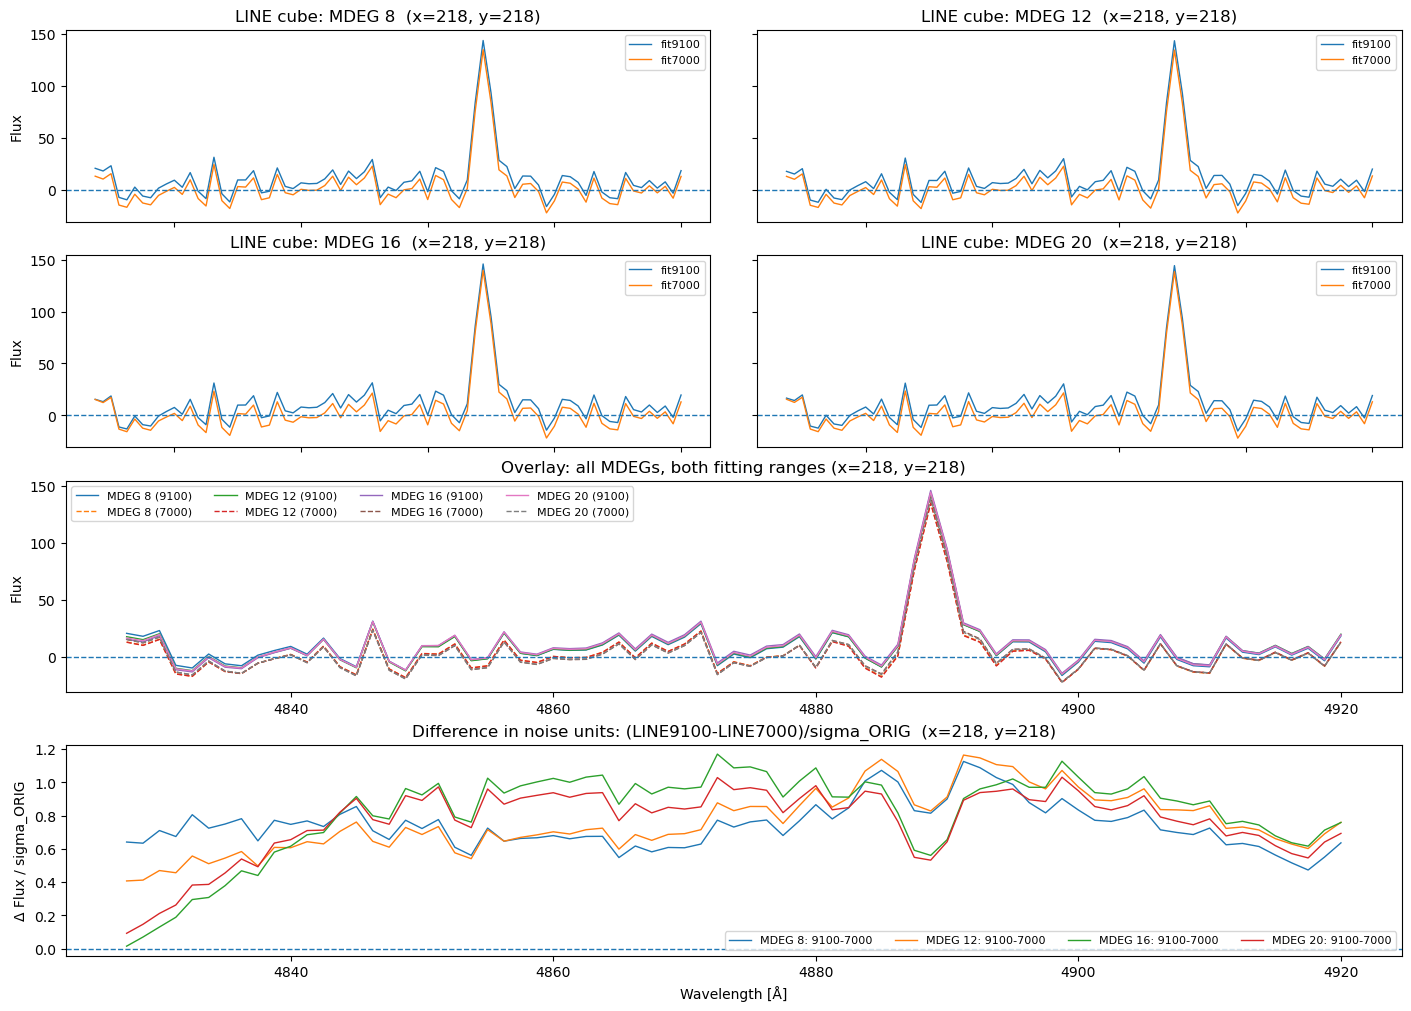

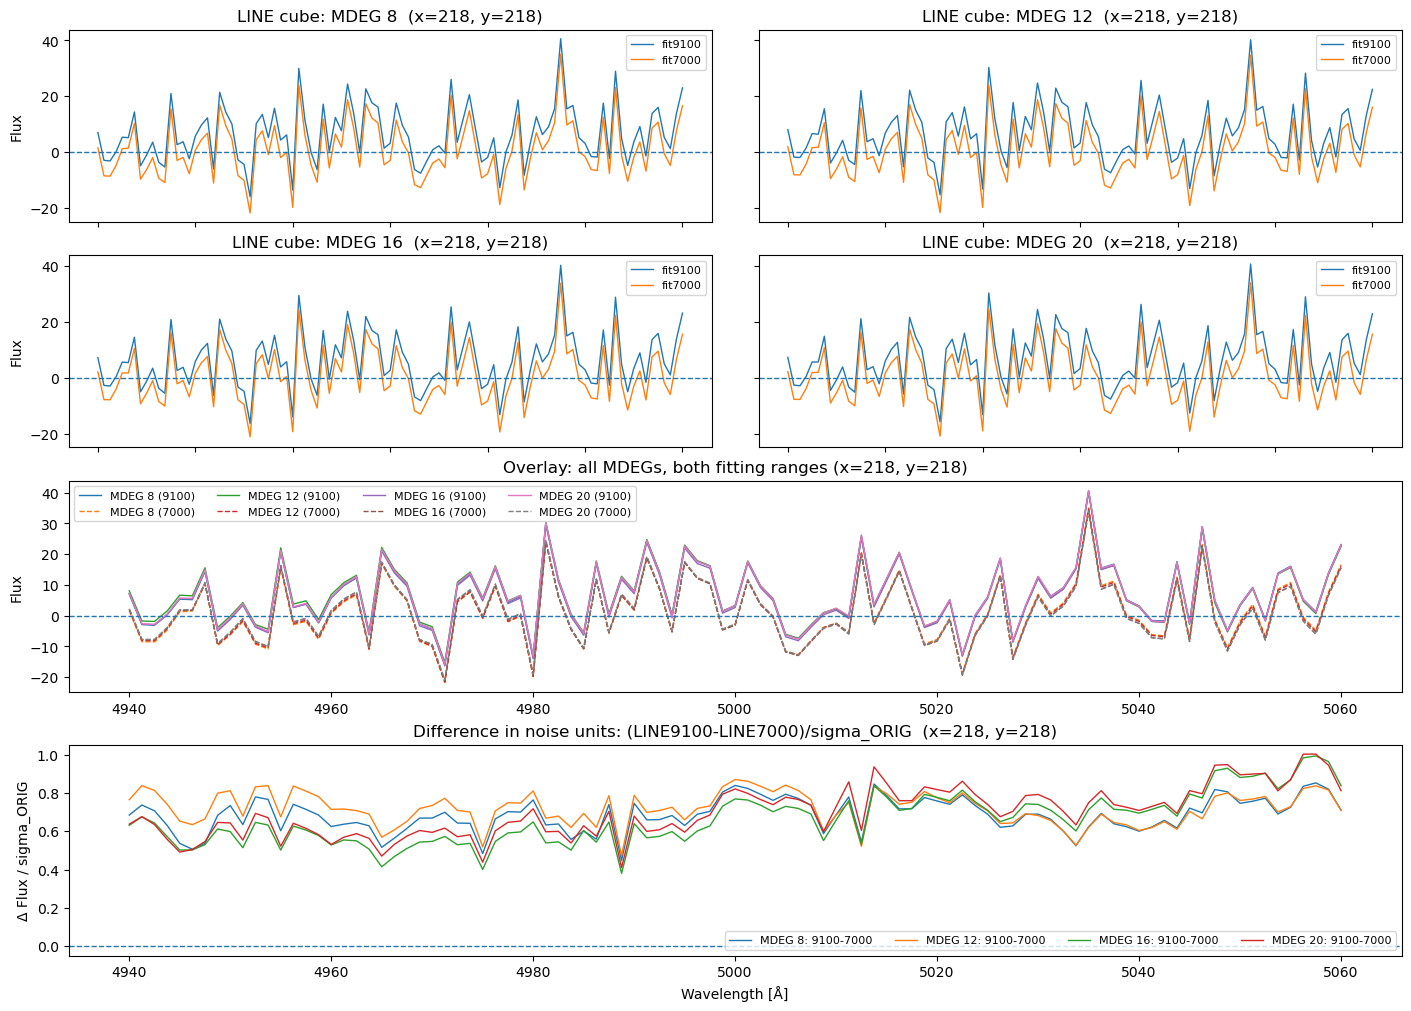

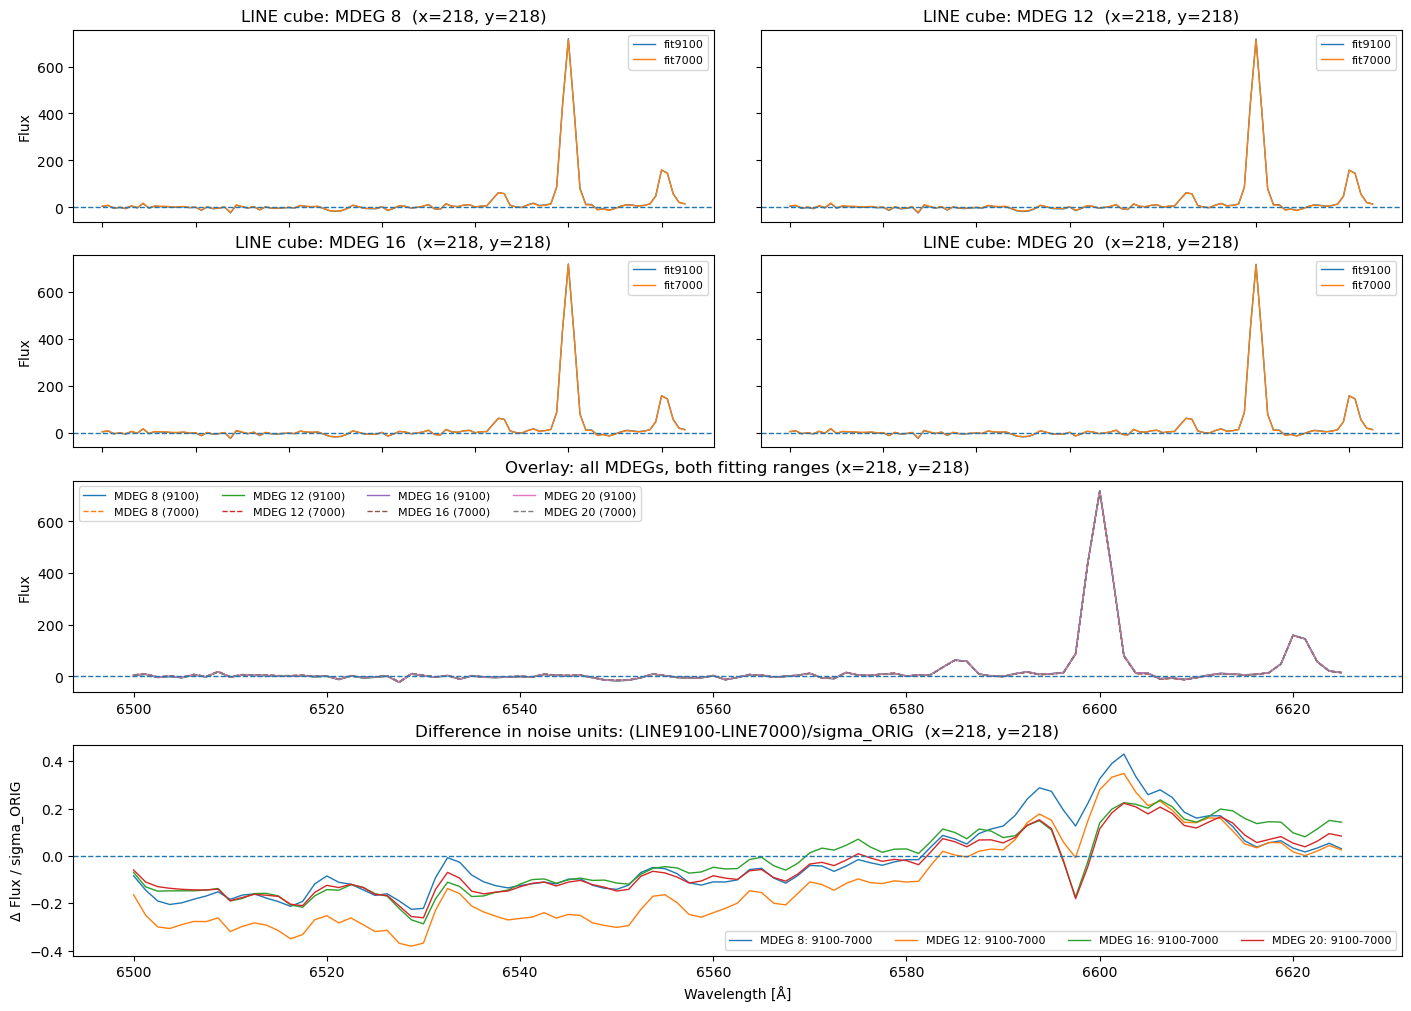

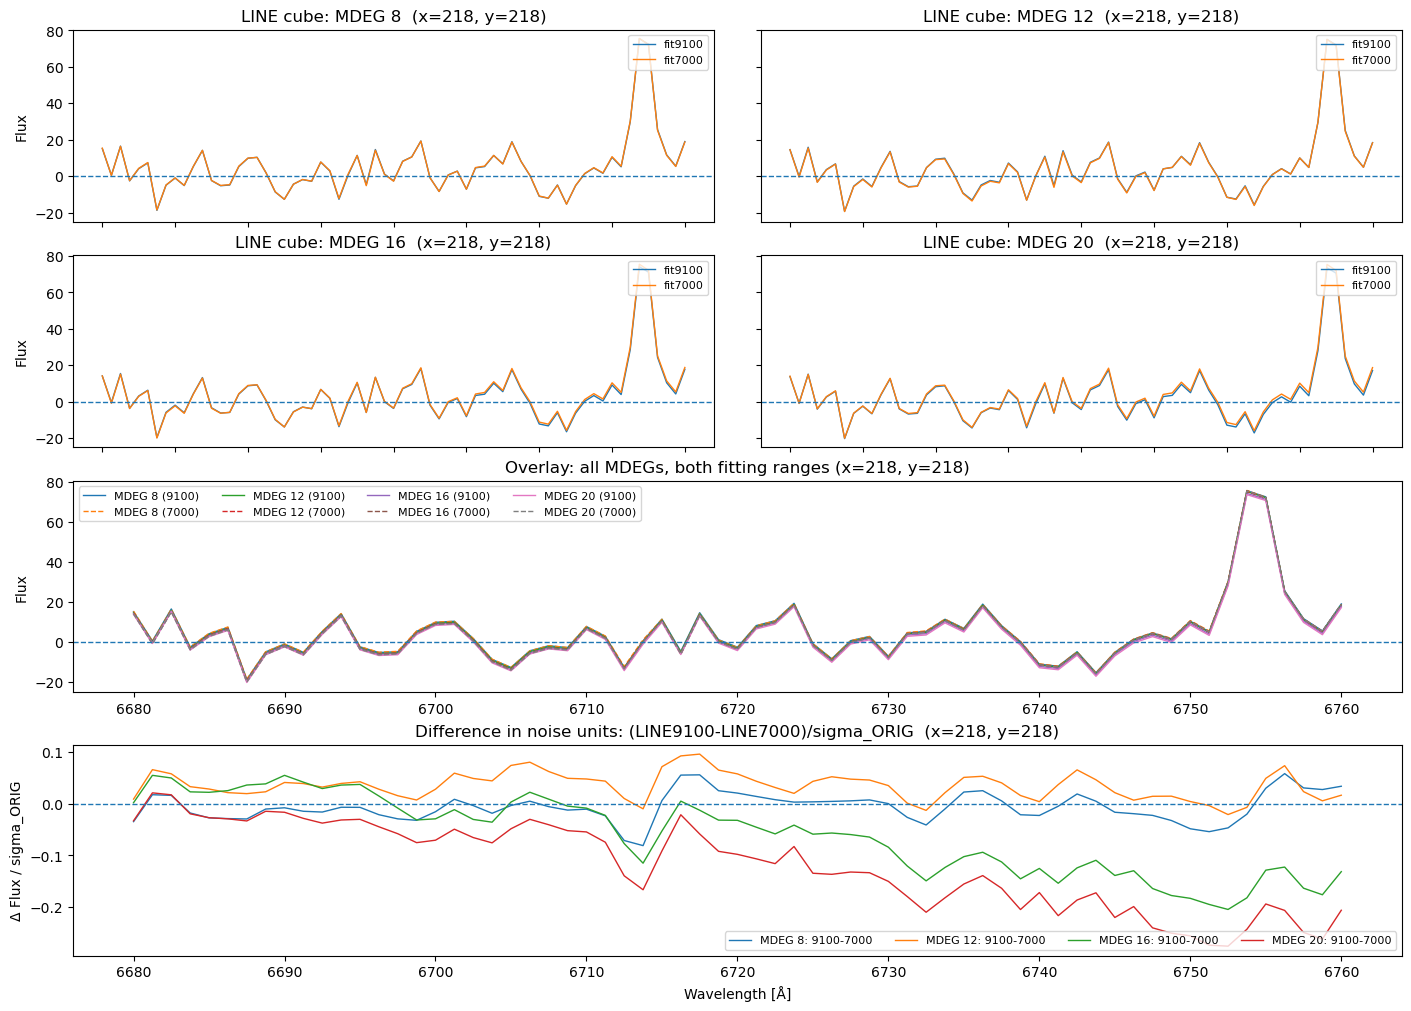

In [3]:
# -----------------------------
# LINE-FLUX INTEGRATED CHANGES (9100 - 7000, per sampled spaxel)
# -----------------------------
def dw_from_header(hdr):
    return float(hdr.get("CDELT3", hdr.get("CD3_3")))

DW_9100 = abs(dw_from_header(hduls_9100[MDEGS[0]][0].header))
DW_7000 = abs(dw_from_header(hduls_7000[MDEGS[0]][0].header))

line_windows = {
    "Hb":   (4847.0, 4876.0),
    "OIII": (5000.0, 5025.0),
    "HaNII":(6545.0, 6585.0),
    "SII":  (6710.0, 6745.0),
}

for lname, (w1, w2) in line_windows.items():
    print("\n" + "-" * 70)
    print(f"{lname} ({w1}-{w2} Å): integrated flux changes (9100 - 7000)")

    idx_9100 = (wave_9100 >= w1) & (wave_9100 <= w2)
    idx_7000 = (wave_7000 >= w1) & (wave_7000 <= w2)
    if idx_9100.sum() == 0 or idx_7000.sum() == 0:
        print("  (no wavelength samples in this window for one dataset)")
        continue

    for mdeg in MDEGS:
        slab_9100 = cubes_9100[mdeg][idx_9100][:, ys, xs]
        slab_7000 = cubes_7000[mdeg][idx_7000][:, ys, xs]

        F9100 = np.nansum(slab_9100, axis=0) * DW_9100
        F7000 = np.nansum(slab_7000, axis=0) * DW_7000

        ok = np.isfinite(F9100) & np.isfinite(F7000)
        if ok.sum() == 0:
            print(f"  MDEG {mdeg}: no overlap-valid spaxels")
            continue

        dF_abs = F9100[ok] - F7000[ok]
        p16a, p50a, p84a = np.nanpercentile(dF_abs, [16, 50, 84])
        print(f"  MDEG {mdeg}: ΔF_abs = F9100-F7000 (p16,p50,p84)=({p16a:.3g}, {p50a:.3g}, {p84a:.3g})  N={ok.sum()}")

        denom_ok = np.abs(F7000[ok]) > 0
        if denom_ok.any():
            dF_pct = dF_abs[denom_ok] / F7000[ok][denom_ok] * 100.0
            p16, p50, p84 = np.nanpercentile(dF_pct, [16, 50, 84])
            print(f"            ΔF/F7000 [%] (p16,p50,p84)=({p16:.3g}, {p50:.3g}, {p84:.3g})  N={denom_ok.sum()}")

        cont_ok = ok & np.isfinite(cont_samp_denom)
        if cont_ok.any():
            dF_cont_pct = (F9100[cont_ok] - F7000[cont_ok]) / np.abs(cont_samp_denom[cont_ok]) * 100.0
            c16, c50, c84 = np.nanpercentile(dF_cont_pct, [16, 50, 84])
            print(f"            ΔF/CONT [%] (p16,p50,p84)=({c16:.3g}, {c50:.3g}, {c84:.3g})  N={cont_ok.sum()}")


# -----------------------------
# REQUIRED ZOOM-INS AROUND KEY LINES
# -----------------------------
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=4800, wmax=4920)  # Hβ
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=4940, wmax=5060)  # [O III]
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=6500, wmax=6625)  # Hα+[N II]
plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=6680, wmax=6760)  # [S II]

# Close only when you're fully done:
for hdul in hduls_9100.values():
    hdul.close()
for hdul in hduls_7000.values():
    hdul.close()
hdul_orig.close()


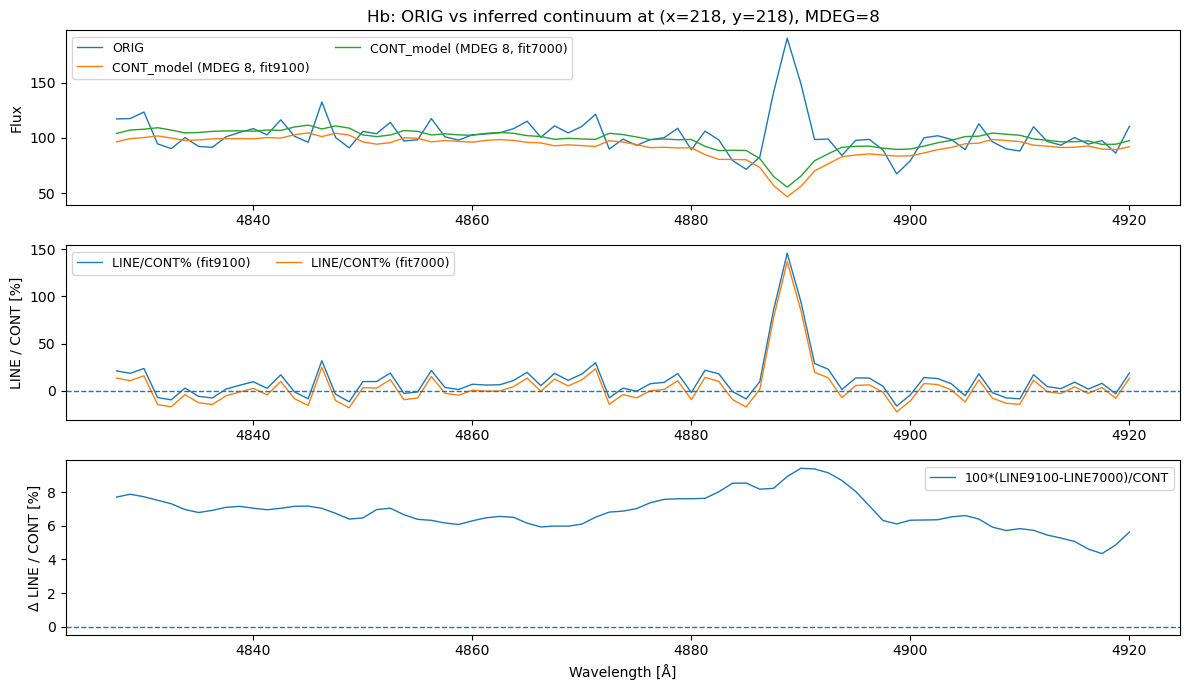

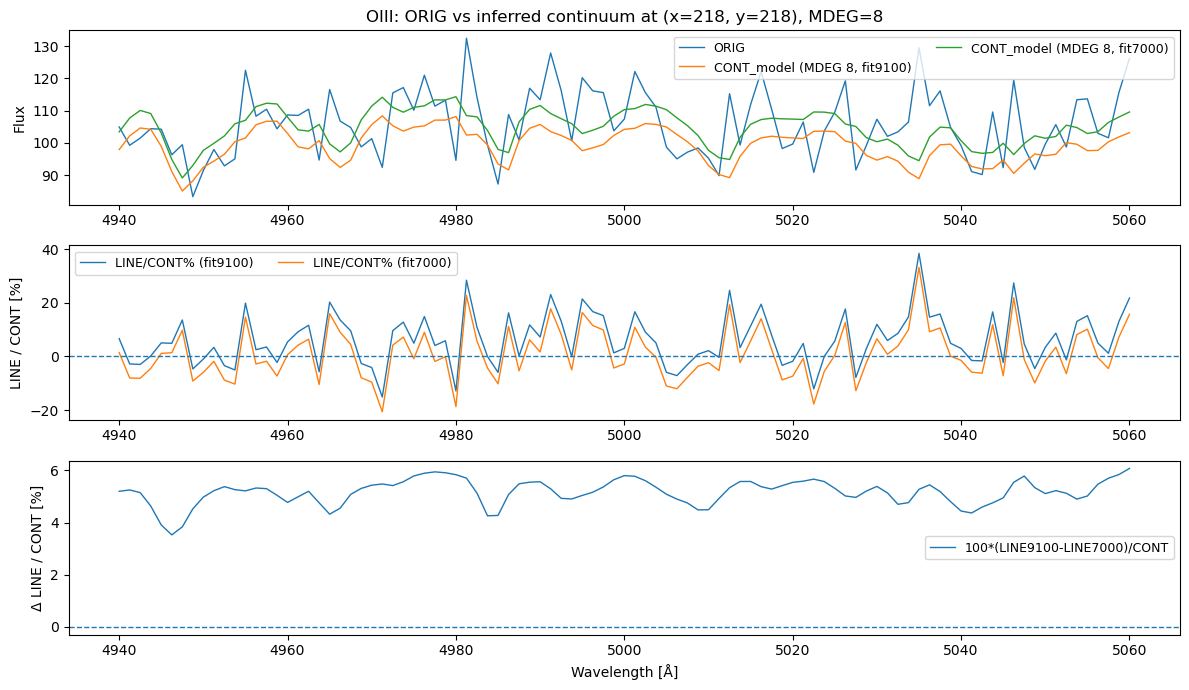

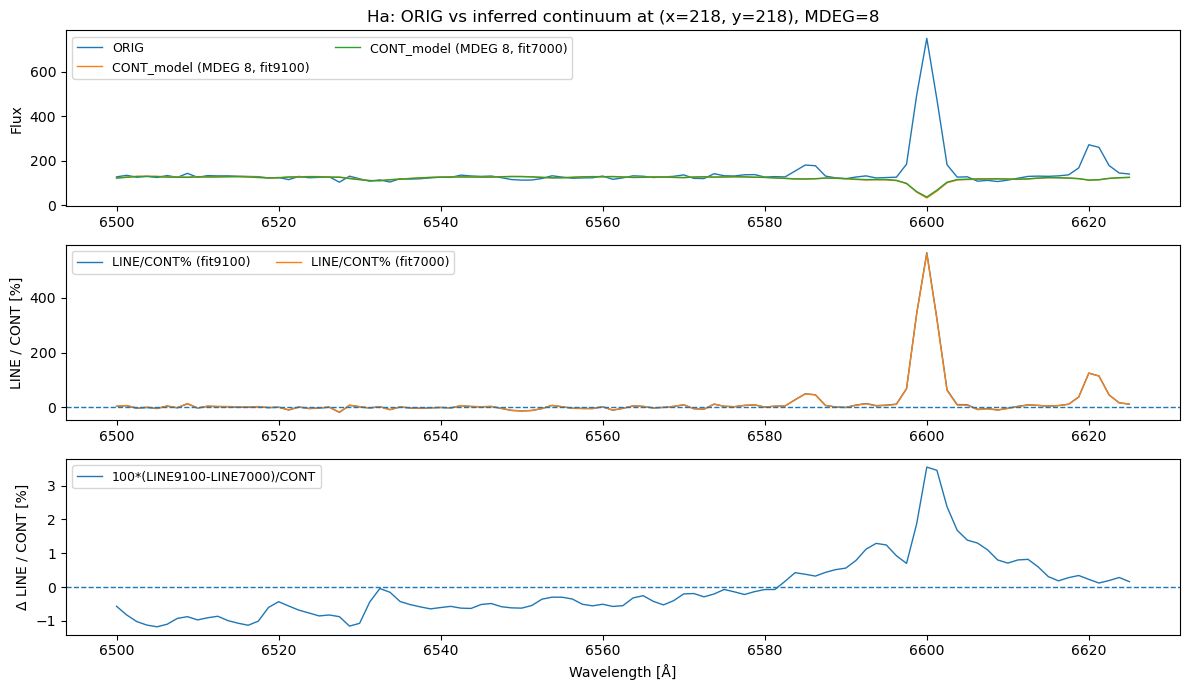

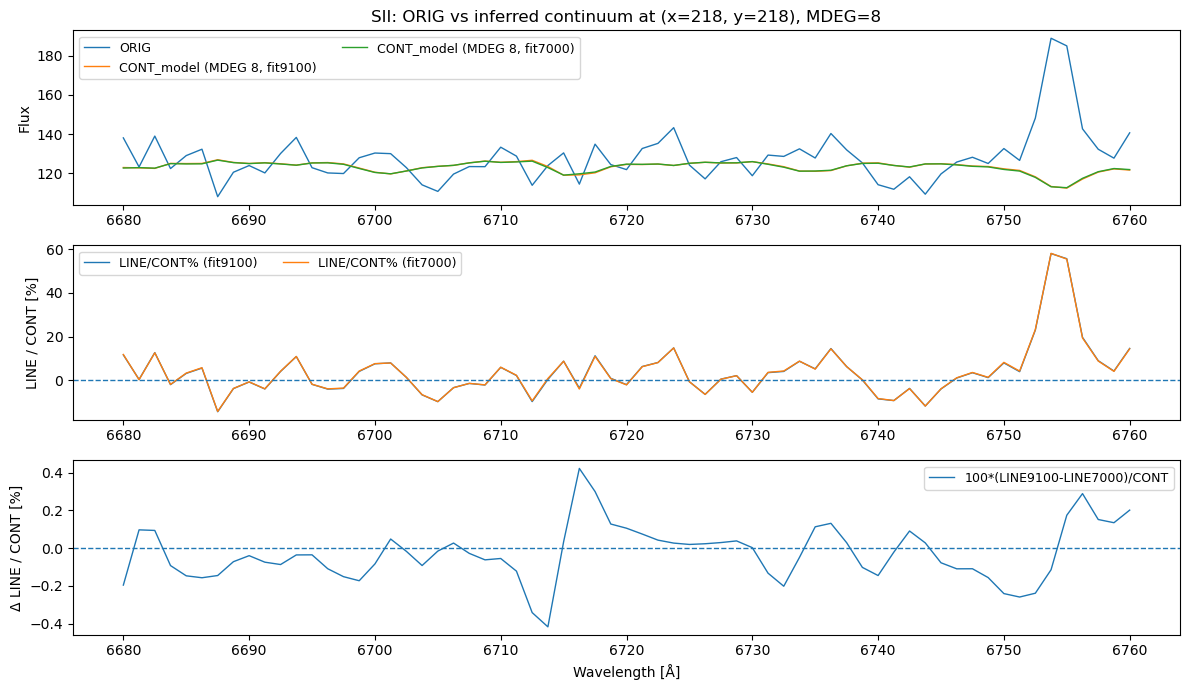

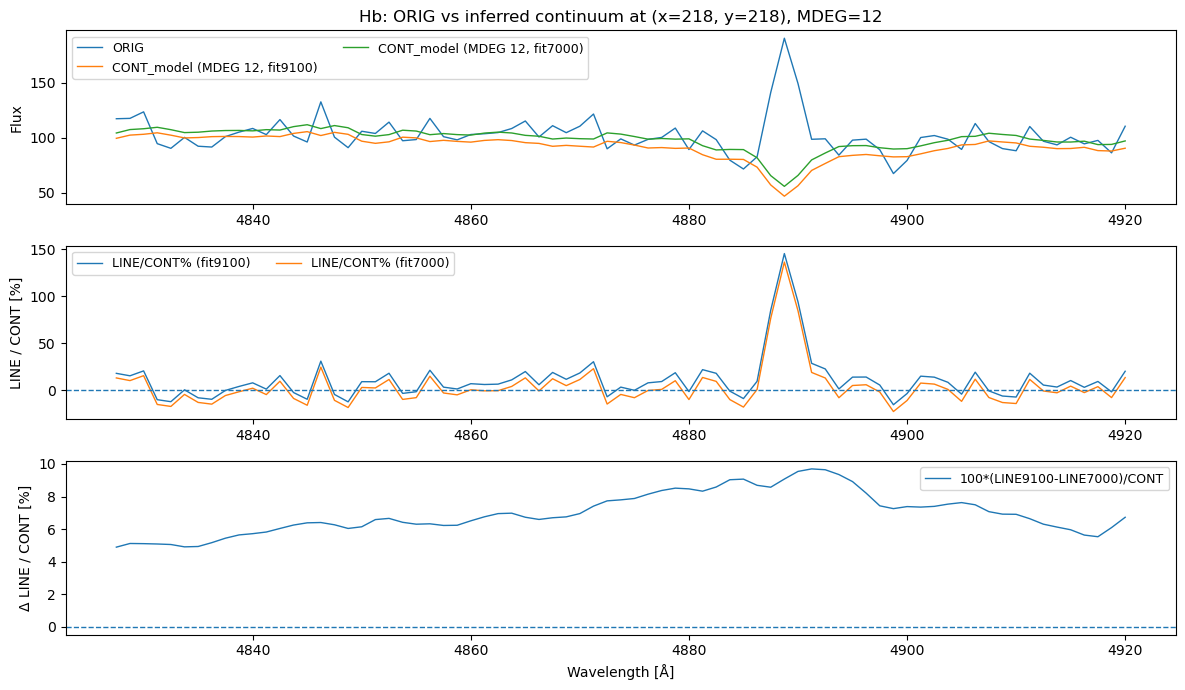

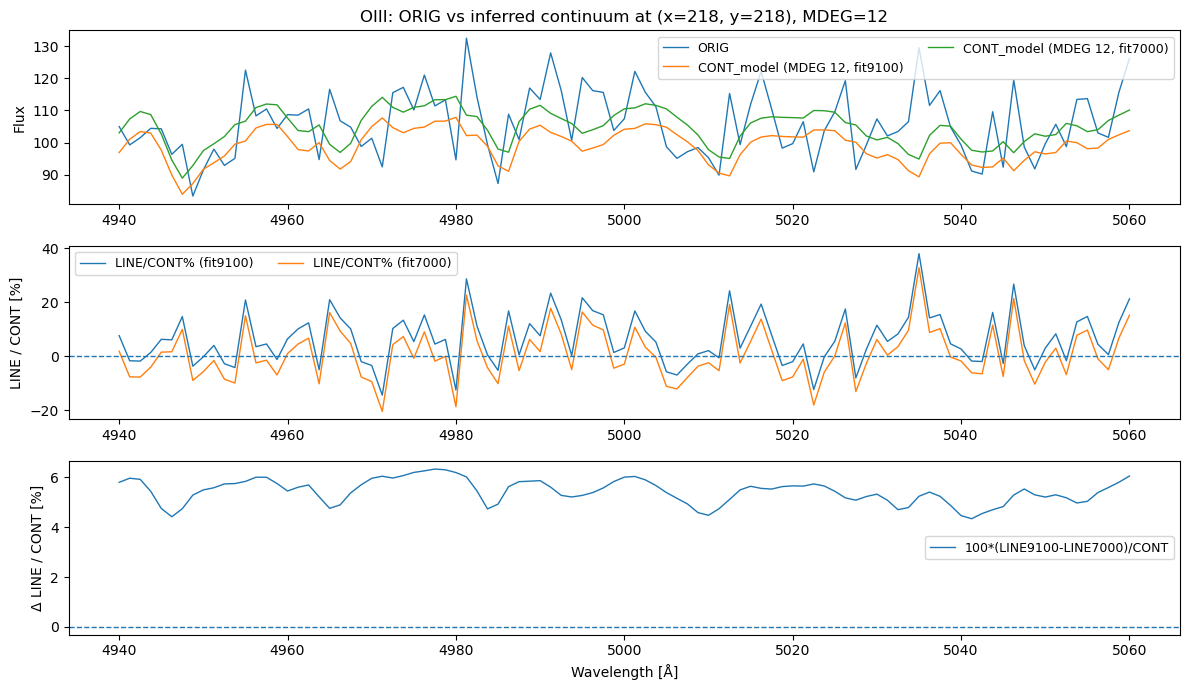

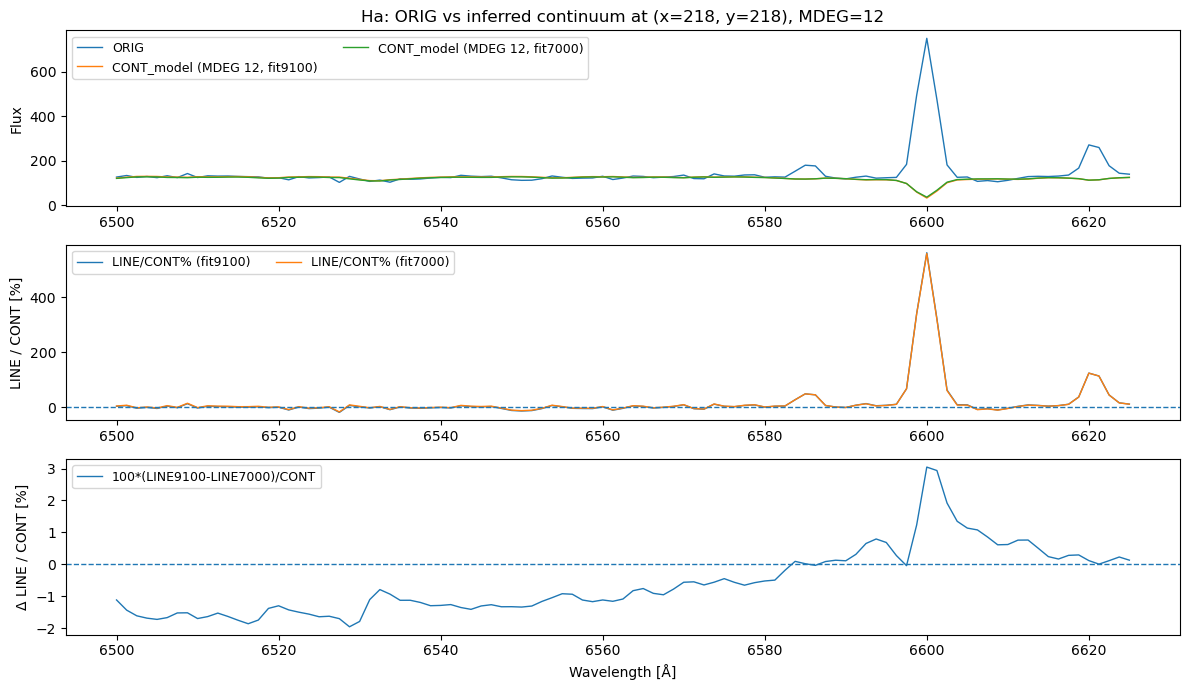

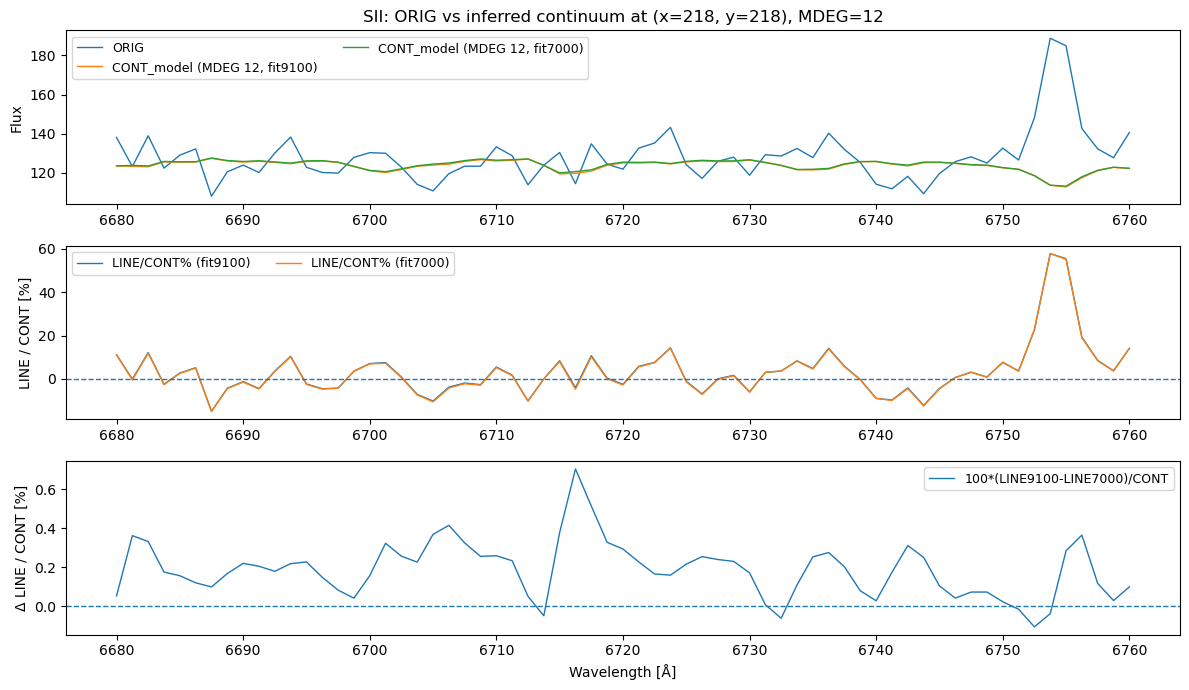

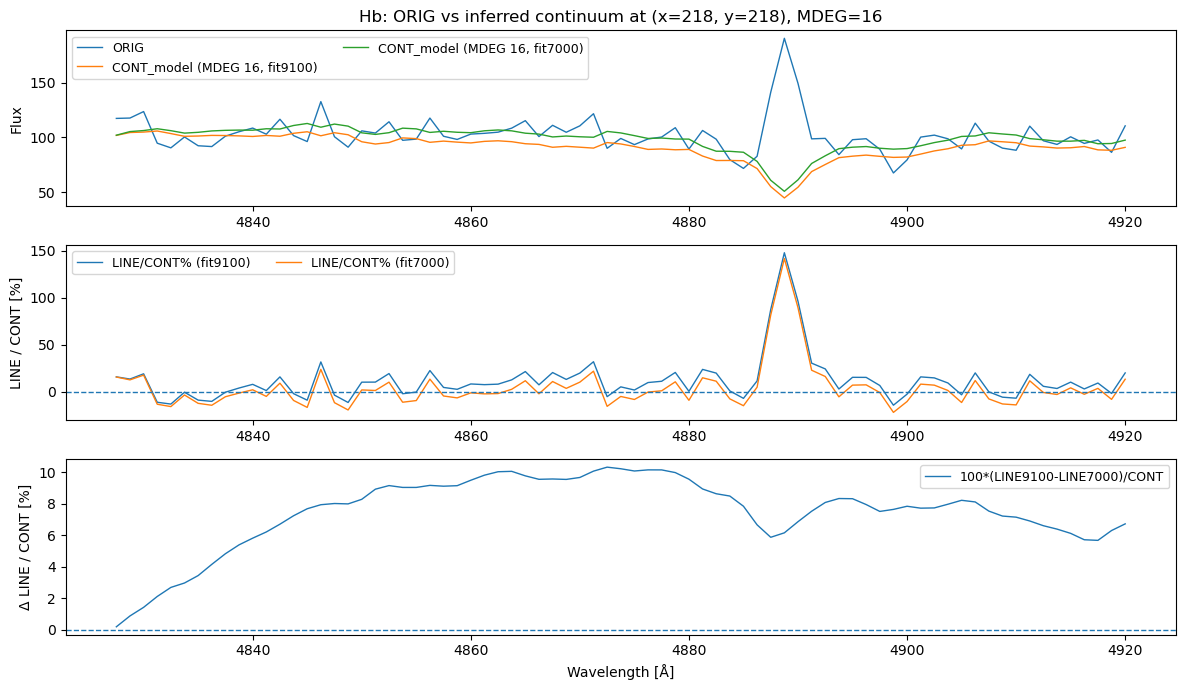

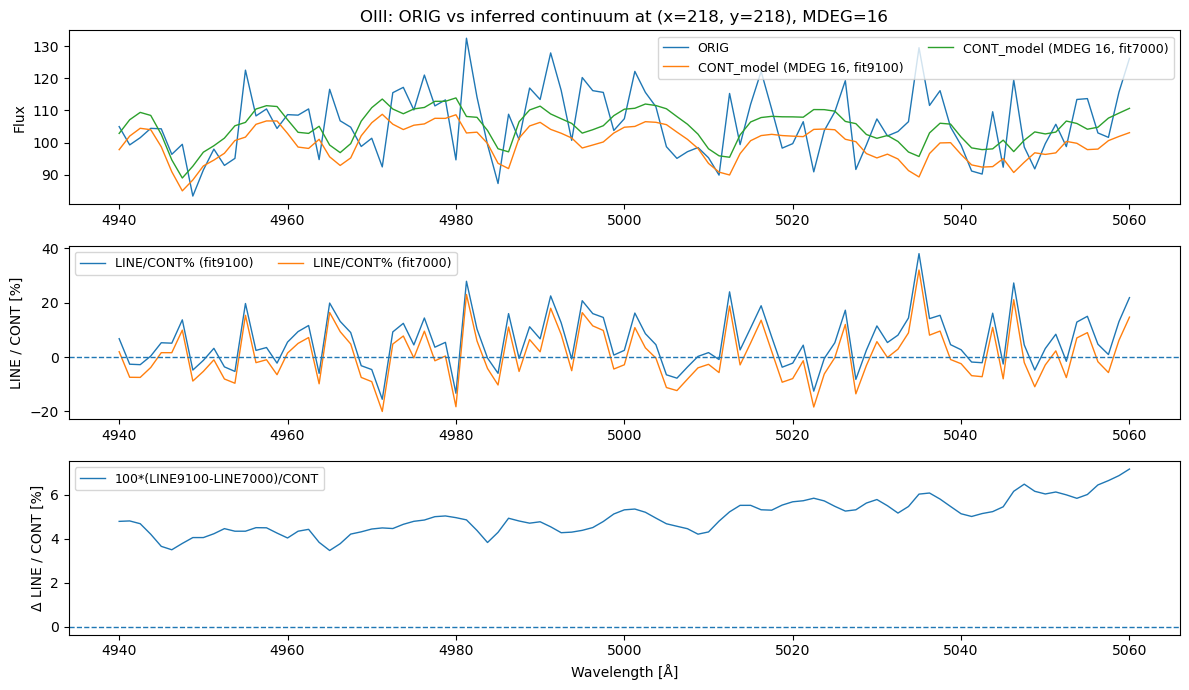

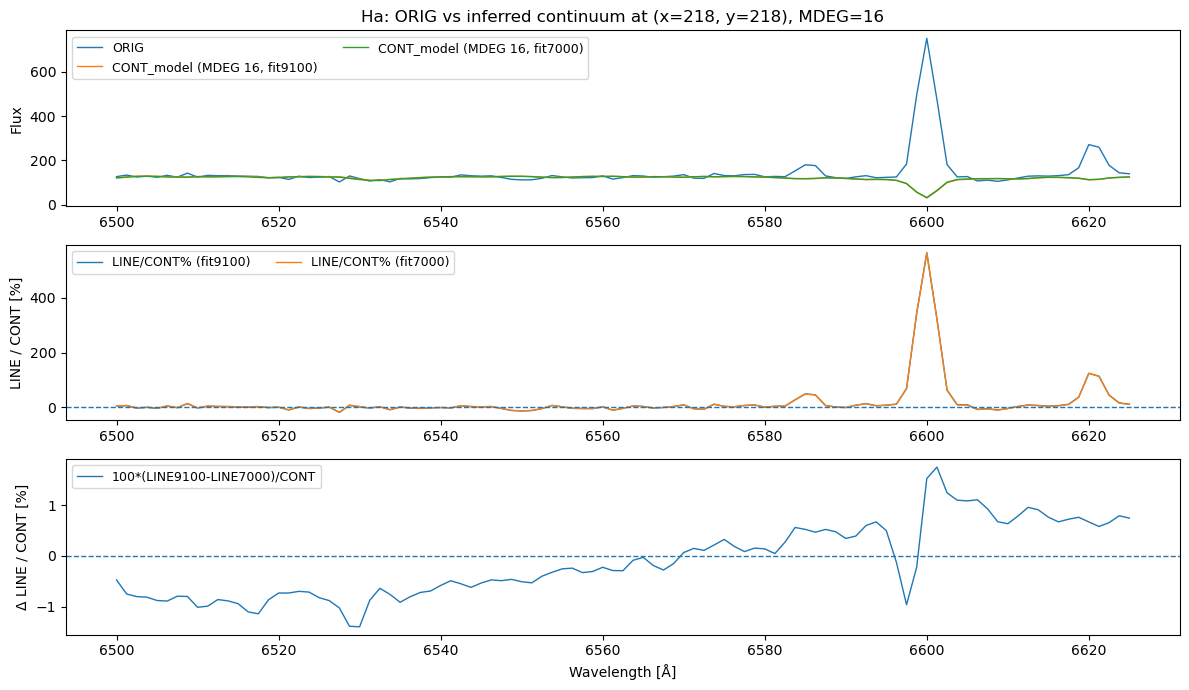

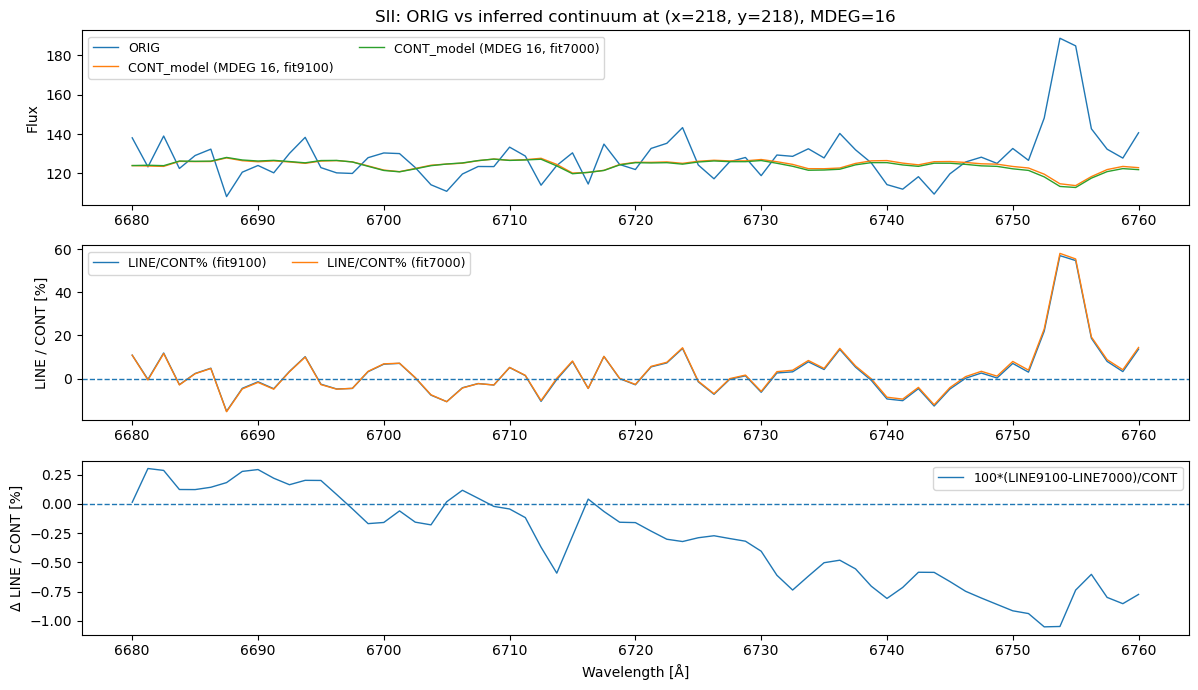

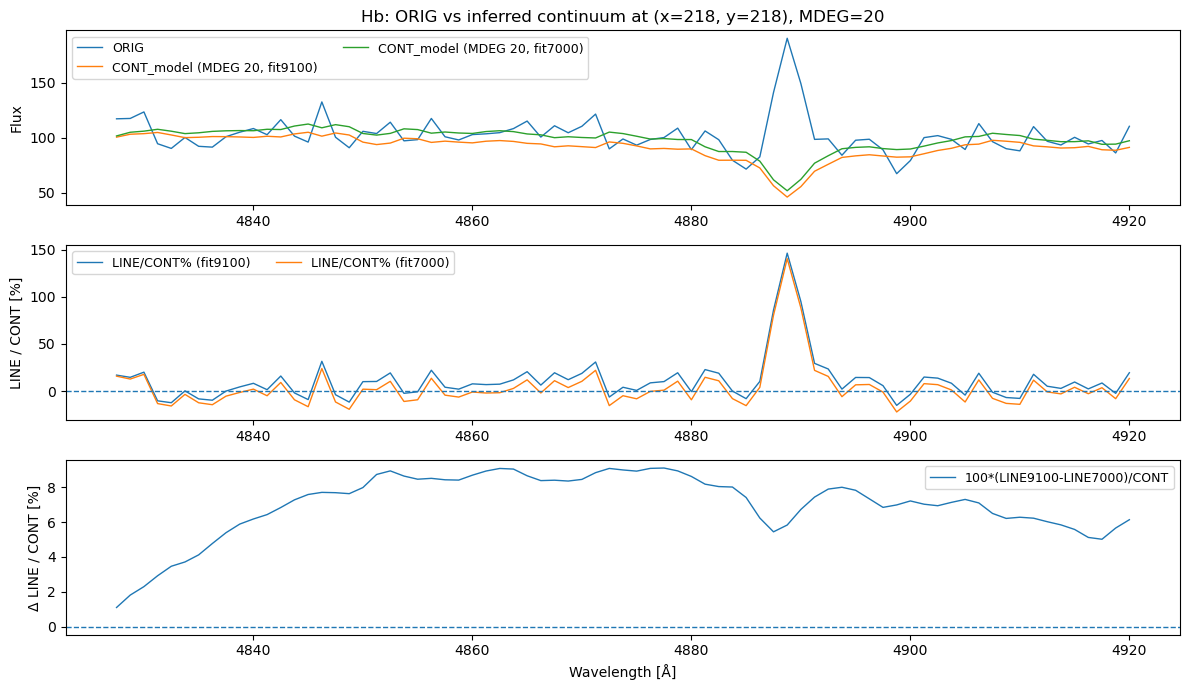

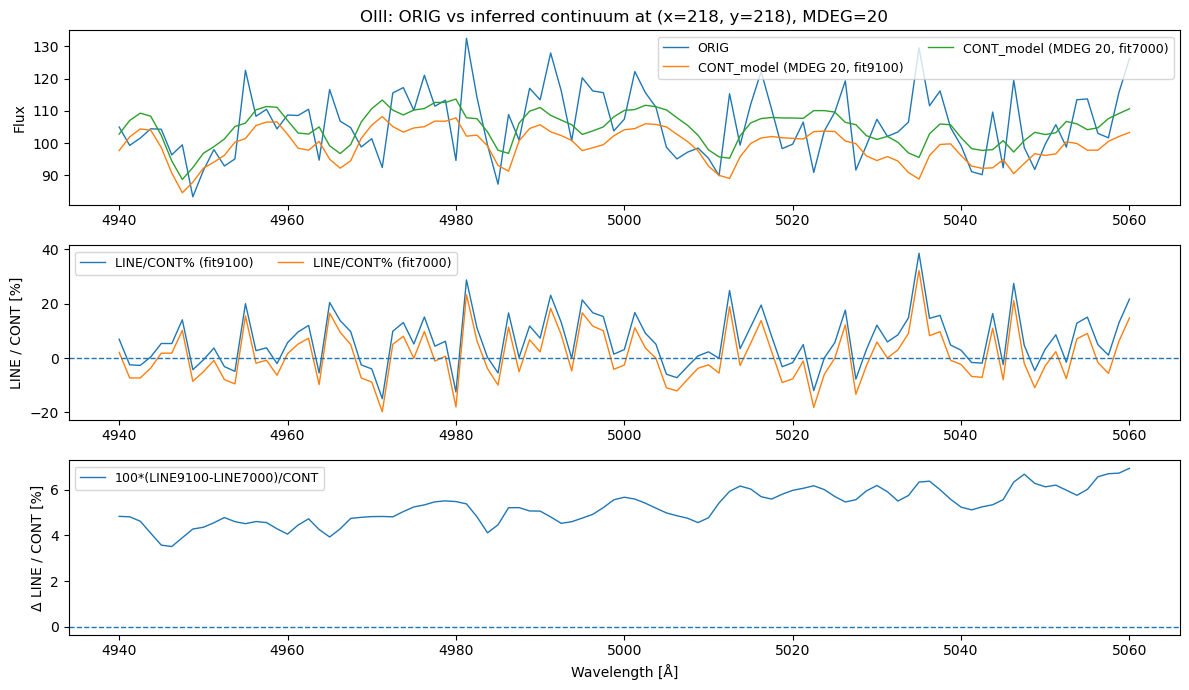

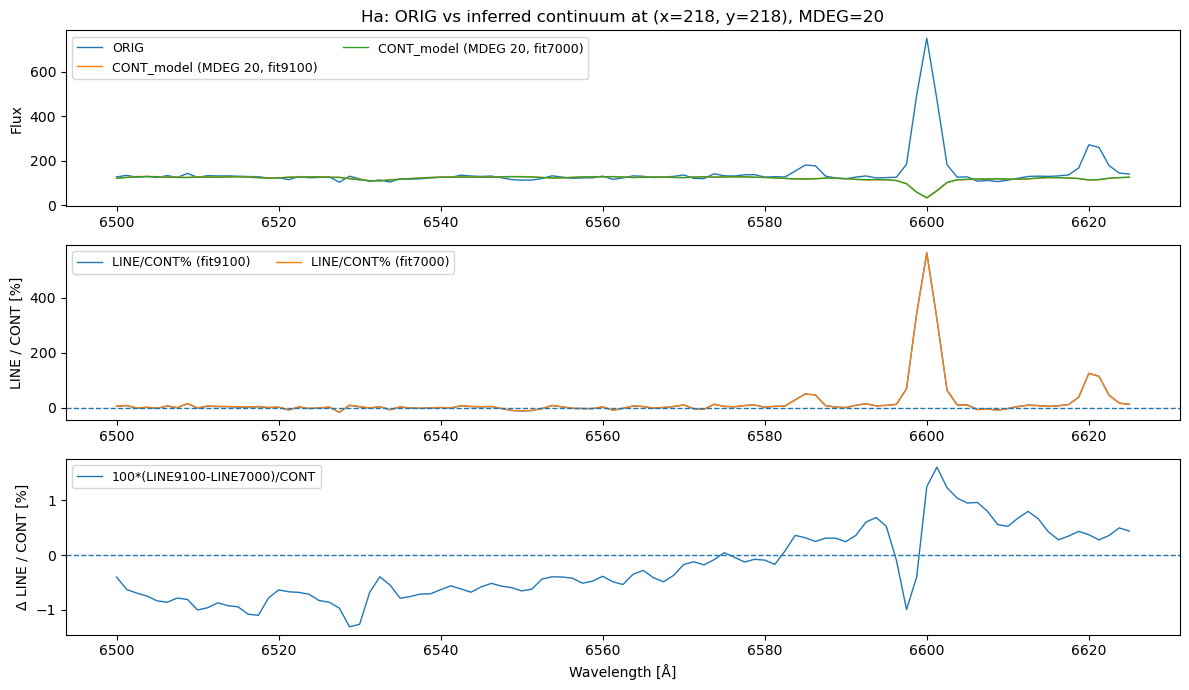

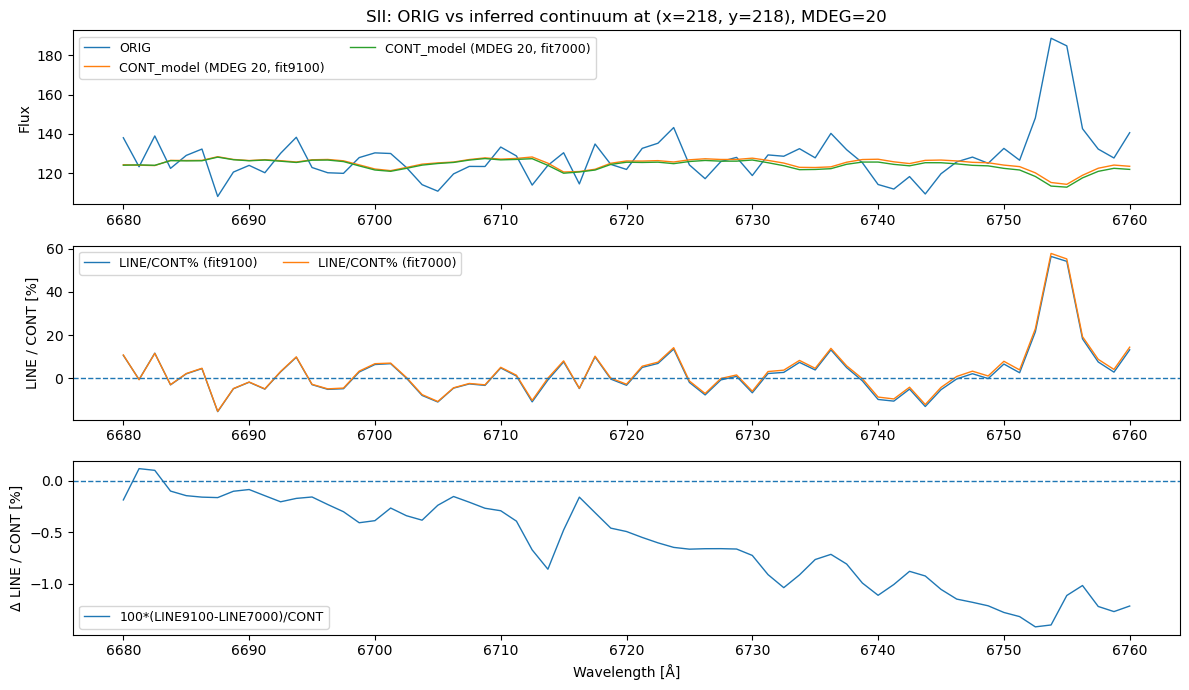

In [4]:
# -----------------------------
# OVERFIT DIAGNOSTIC: inferred continuum model from ORIG cube
# Compare fitting ranges (9100 vs 7000) at fixed MDEG
# -----------------------------
def interp_to_refwave(spec_in, wave_in, wave_out):
    ok = np.isfinite(spec_in) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out, np.nan, dtype=float)
    return np.interp(wave_out, wave_in[ok], spec_in[ok], left=np.nan, right=np.nan)

def local_continuum_from_sidebands(orig_on_ref, wave, sidebands):
    m = np.zeros_like(wave, dtype=bool)
    for w1, w2 in sidebands:
        m |= (wave >= w1) & (wave <= w2)
    vals = orig_on_ref[m]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan
    return np.nanmedian(vals)

SIDE = {
    "Hb":   [(4825, 4842), (4882, 4900)],
    "OIII": [(4985, 4995), (5032, 5050)],
    "Ha":   [(6505, 6535), (6595, 6620)],
    "SII":  [(6685, 6705), (6750, 6770)],
}

def plot_overfit_diagnostic(x, y, mdeg=20, line_name="Ha", wmin=6500, wmax=6625):
    w = wave_7000
    sel = (w >= wmin) & (w <= wmax)

    orig_ref = interp_to_refwave(cube_orig[:, y, x], wave_orig, w)

    cont_local = local_continuum_from_sidebands(orig_ref, w, SIDE[line_name])
    denom = np.nanmax([np.abs(cont_local), CONT_FLOOR])

    line_9100 = interp_to_refwave(cubes_9100[mdeg][:, y, x], wave_9100, w)
    line_7000 = cubes_7000[mdeg][:, y, x]

    cont_model_9100 = orig_ref - line_9100
    cont_model_7000 = orig_ref - line_7000

    dline = line_9100 - line_7000
    dline_pct = 100.0 * dline / denom

    plt.figure(figsize=(12, 7))

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(w[sel], orig_ref[sel], lw=1, label="ORIG")
    ax1.plot(w[sel], cont_model_9100[sel], lw=1, label=f"CONT_model (MDEG {mdeg}, fit9100)")
    ax1.plot(w[sel], cont_model_7000[sel], lw=1, label=f"CONT_model (MDEG {mdeg}, fit7000)")
    ax1.set_ylabel("Flux")
    ax1.set_title(f"{line_name}: ORIG vs inferred continuum at (x={x}, y={y}), MDEG={mdeg}")
    ax1.legend(ncol=2, fontsize=9)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(w[sel], 100.0 * line_9100[sel] / denom, lw=1, label="LINE/CONT% (fit9100)")
    ax2.plot(w[sel], 100.0 * line_7000[sel] / denom, lw=1, label="LINE/CONT% (fit7000)")
    ax2.axhline(0, ls="--", lw=1)
    ax2.set_ylabel("LINE / CONT [%]")
    ax2.legend(ncol=2, fontsize=9)

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    good = sel & np.isfinite(dline_pct)
    if good.any():
        ax3.plot(w[good], dline_pct[good], lw=1, label="100*(LINE9100-LINE7000)/CONT")
    ax3.axhline(0, ls="--", lw=1)
    ax3.set_ylabel("Δ LINE / CONT [%]")
    ax3.set_xlabel("Wavelength [Å]")
    ax3.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


for mdeg in (8, 12, 16, 20):
    plot_overfit_diagnostic(XPIX, YPIX, mdeg=mdeg, line_name="Hb", wmin=4800, wmax=4920)
    plot_overfit_diagnostic(XPIX, YPIX, mdeg=mdeg, line_name="OIII", wmin=4940, wmax=5060)
    plot_overfit_diagnostic(XPIX, YPIX, mdeg=mdeg, line_name="Ha", wmin=6500, wmax=6625)
    plot_overfit_diagnostic(XPIX, YPIX, mdeg=mdeg, line_name="SII", wmin=6680, wmax=6760)
